![Illustration agricole](agriculture.png)

# Rapport synthétique métier sur le rendement agricole


## Résumé exécutif

Ce notebook est rédigé comme un **rapport synthétique métier**. Il présente l'analyse exploratoire des données, les variables les plus influentes et les choix retenus pour la suite du projet. Les traitements opérationnels de construction du dataset consolidé et la modélisation sont réalisés séparément dans `modelisation.ipynb`.

Principaux résultats :

- le dataset `crop_yield.csv` est très lisible et très propre, mais il semble aussi très artificiel ou déjà fortement nettoyé ;
- dans ce dataset, la pluie est le facteur le plus structurant du rendement, devant la température ;
- l'irrigation et la fertilisation ont un effet net, alors que les écarts entre cultures restent plus faibles ;
- aucune variable de surface en hectares n'est disponible ;
- quelques valeurs atypiques devront être traitées avant la modélisation ;
- le second jeu de données sert surtout à documenter les choix de structuration et d'enrichissement de la future base d'entraînement.


## Comment lire le dataset `crop_yield.csv`

Le dataset `crop_yield.csv` est un jeu de données simple, très propre et facile à lire. Il fonctionne bien pour une première analyse exploratoire, car il permet de visualiser rapidement les relations entre pluie, température, pratiques culturales et rendement.

Ce que ce dataset permet de bien faire :

- comprendre les ordres de grandeur du rendement ;
- visualiser les effets apparents de la pluie, de la température, de l'irrigation et du fertilisant ;
- produire un rapport métier lisible avec des graphiques et des tableaux faciles à interpréter.

Ce qu'il ne permet pas de faire directement :

- mesurer l'effet de la taille des parcelles, car aucune surface en hectares n'est fournie ;
- conclure de façon certaine sur des recommandations terrain universelles ;
- ignorer les quelques valeurs atypiques repérées dans la cible.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ModuleNotFoundError:
    def display(obj):
        print(obj)

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
plt.rcParams["figure.figsize"] = (12, 6)

data = pd.read_csv("data/crop_yield.csv")
viz_sample = data.sample(n=min(50_000, len(data)), random_state=42)
scatter_sample = data.sample(n=min(20_000, len(data)), random_state=42)

print(f"Dimensions du dataset : {data.shape[0]:,} lignes x {data.shape[1]} colonnes")
print(f"Taille de l'échantillon pour les graphiques lourds : {len(viz_sample):,} lignes")


Dimensions du dataset : 1,000,000 lignes x 10 colonnes
Taille de l'échantillon pour les graphiques lourds : 50,000 lignes


## Lecture du dataset `crop_yield.csv`


Cette première partie se concentre sur `crop_yield.csv`. Avant d'interpréter les rendements, il faut vérifier que cette base est lisible, complète et cohérente. Les éléments ci-dessous présentent sa taille, ses variables et ses ordres de grandeur principaux.

In [2]:
print(f"data.info() :")
data.info()
print("")
print(f"data.describe() :")
display(data.describe().T.drop(columns="count"))

categorical_summary_columns = [
    column
    for column in data.columns
    if pd.api.types.is_object_dtype(data[column])
    or pd.api.types.is_string_dtype(data[column])
    or pd.api.types.is_bool_dtype(data[column])
]
print("")
print(f"data[categorical_summary_columns].describe() :")
display(data[categorical_summary_columns].describe().T)


data.info() :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Region                  1000000 non-null  object 
 1   Soil_Type               1000000 non-null  object 
 2   Crop                    1000000 non-null  object 
 3   Rainfall_mm             1000000 non-null  float64
 4   Temperature_Celsius     1000000 non-null  float64
 5   Fertilizer_Used         1000000 non-null  bool   
 6   Irrigation_Used         1000000 non-null  bool   
 7   Weather_Condition       1000000 non-null  object 
 8   Days_to_Harvest         1000000 non-null  int64  
 9   Yield_tons_per_hectare  1000000 non-null  float64
dtypes: bool(2), float64(3), int64(1), object(4)
memory usage: 62.9+ MB

data.describe() :


,mean,std,min,25%,50%,75%,max
Rainfall_mm,549.98,259.85,100.00,324.89,550.12,774.74,"1,000.00"
Temperature_Celsius,27.50,7.22,15.00,21.25,27.51,33.75,40.00
Days_to_Harvest,104.50,25.95,60.00,82.00,104.00,127.00,149.00
Yield_tons_per_hectare,4.65,1.70,-1.15,3.42,4.65,5.88,9.96



data[categorical_summary_columns].describe() :


,count,unique,top,freq
Region,1000000,4,North,250173
Soil_Type,1000000,6,Sandy,167119
Crop,1000000,6,Maize,166824
Fertilizer_Used,1000000,2,False,500060
Irrigation_Used,1000000,2,False,500509
Weather_Condition,1000000,3,Sunny,333790


### Données manquantes, doublons et cohérence générale


Cette vérification répond à une question simple pour un lecteur métier : peut-on faire confiance au jeu de données avant de l'utiliser pour expliquer les rendements ou entraîner un modèle ?

In [3]:
missing_values = data.isna().sum().to_frame("nb_nan")
missing_values["pct_nan"] = (missing_values["nb_nan"] / len(data) * 100).round(4)
missing_values = missing_values.sort_values(["nb_nan", "pct_nan"], ascending=False)

duplicate_count = int(data.duplicated().sum())
categorical_quality_columns = [
    column
    for column in data.columns
    if pd.api.types.is_object_dtype(data[column])
    or pd.api.types.is_string_dtype(data[column])
    or pd.api.types.is_bool_dtype(data[column])
]
cardinality = data[categorical_quality_columns].nunique(dropna=False).to_frame("nb_modalites")

print(f"Nombre total de valeurs manquantes : {int(missing_values['nb_nan'].sum()):,}")
print(f"Nombre de lignes dupliquées complètes : {duplicate_count:,}")

display(missing_values)
display(cardinality.sort_values("nb_modalites", ascending=False))


Nombre total de valeurs manquantes : 0
Nombre de lignes dupliquées complètes : 0


,nb_nan,pct_nan
Region,0,0.00
Soil_Type,0,0.00
Crop,0,0.00
Rainfall_mm,0,0.00
Temperature_Celsius,0,0.00
Fertilizer_Used,0,0.00
Irrigation_Used,0,0.00
Weather_Condition,0,0.00
Days_to_Harvest,0,0.00
Yield_tons_per_hectare,0,0.00


,nb_modalites
Soil_Type,6
Crop,6
Region,4
Weather_Condition,3
Fertilizer_Used,2
Irrigation_Used,2


### Valeurs atypiques


Les valeurs extrêmes ne remettent pas forcément le dataset en cause, mais elles peuvent fausser les moyennes et perturber la modélisation. Le tableau suivant aide à repérer les anomalies à discuter.

In [4]:
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()

q1 = data[numeric_columns].quantile(0.25)
q3 = data[numeric_columns].quantile(0.75)
iqr = q3 - q1
lower_bounds = q1 - 1.5 * iqr
upper_bounds = q3 + 1.5 * iqr

outlier_counts = ((data[numeric_columns] < lower_bounds) | (data[numeric_columns] > upper_bounds)).sum()
outlier_summary = pd.DataFrame({
    "borne_basse": lower_bounds,
    "borne_haute": upper_bounds,
    "nb_outliers": outlier_counts,
})
outlier_summary["pct_outliers"] = (outlier_summary["nb_outliers"] / len(data) * 100).round(4)
outlier_summary = outlier_summary.sort_values("nb_outliers", ascending=False)

negative_yield_count = int((data["Yield_tons_per_hectare"] < 0).sum())

print(f"Nombre de rendements négatifs : {negative_yield_count:,}")
display(outlier_summary)
print("Yield_tons_per_hectare négatifs (10 premiers) :")
display(
    data.loc[data["Yield_tons_per_hectare"] < 0, numeric_columns]
    .sort_values("Yield_tons_per_hectare")
    .head(10)
)


Nombre de rendements négatifs : 231


,borne_basse,borne_haute,nb_outliers,pct_outliers
Yield_tons_per_hectare,-0.27,9.57,84,0.01
Rainfall_mm,-349.88,"1,449.51",0,0.00
Temperature_Celsius,2.51,52.50,0,0.00
Days_to_Harvest,14.50,194.50,0,0.00


Yield_tons_per_hectare négatifs (10 premiers) :


,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
773387,174.91,16.58,128,-1.15
889758,107.62,19.00,127,-0.88
77504,120.42,22.81,120,-0.84
737655,142.76,21.88,102,-0.82
387230,120.57,20.12,144,-0.80
770740,133.18,24.93,72,-0.73
682138,112.40,17.17,142,-0.70
243824,120.73,38.34,97,-0.67
363782,102.04,20.43,123,-0.65
572365,115.34,30.60,86,-0.60


## Répartition générale des variables


Les graphiques suivants montrent comment se répartissent la pluie, la température, le temps jusqu'à la récolte et le rendement. Ils donnent une première idée de la variabilité du contexte agronomique observé.

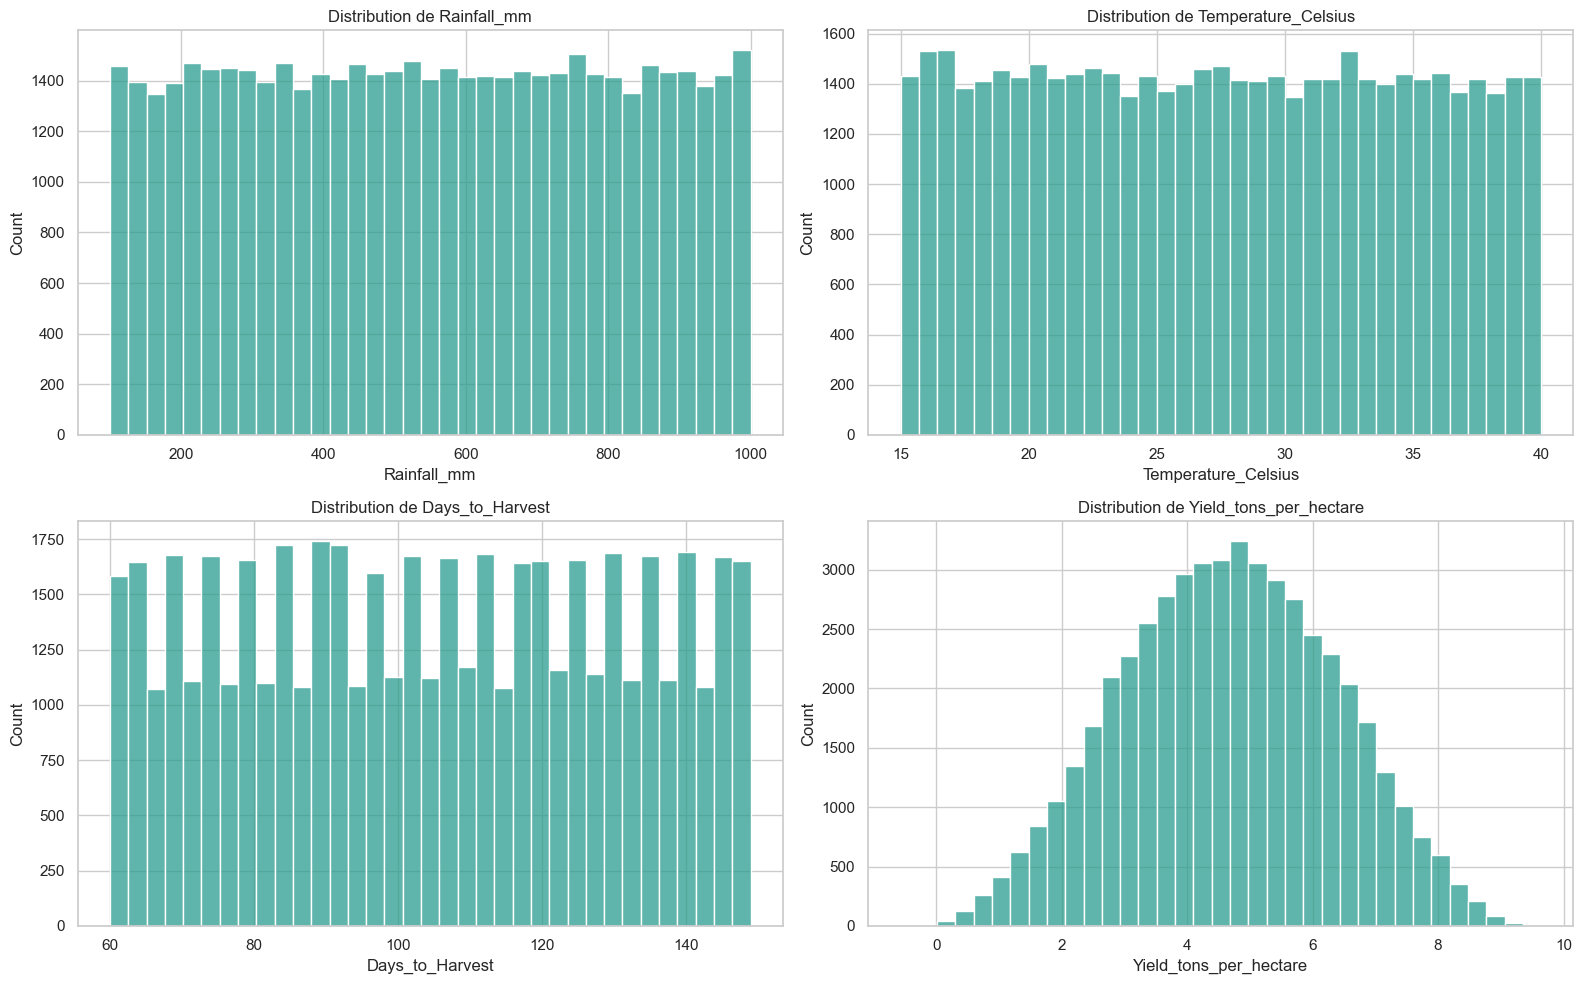

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, column in zip(axes.flat, numeric_columns):
    sns.histplot(data=viz_sample, x=column, bins=35, ax=ax, color="#2a9d8f")
    ax.set_title(f"Distribution de {column}")

plt.tight_layout()
plt.show()


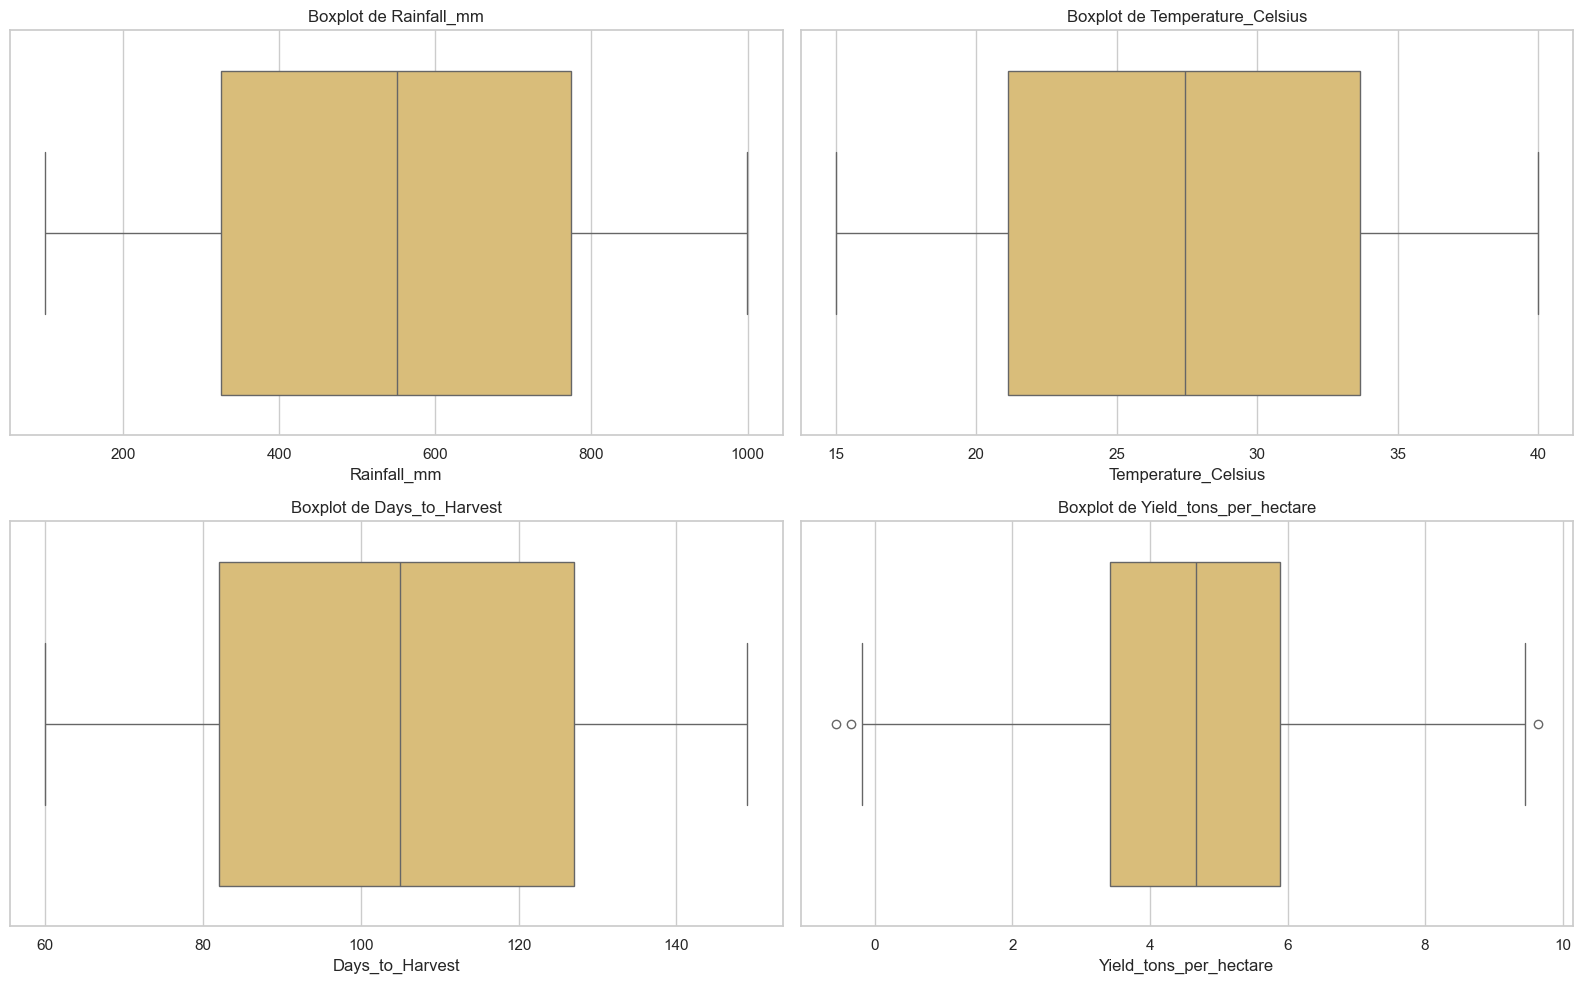

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, column in zip(axes.flat, numeric_columns):
    sns.boxplot(data=viz_sample, x=column, ax=ax, color="#e9c46a")
    ax.set_title(f"Boxplot de {column}")

plt.tight_layout()
plt.show()


## Comparaison des catégories

Cette section compare les grandes catégories du dataset : cultures, régions, types de sol et météo observée. Pour un public métier, elle permet surtout de voir si certaines catégories se détachent clairement.


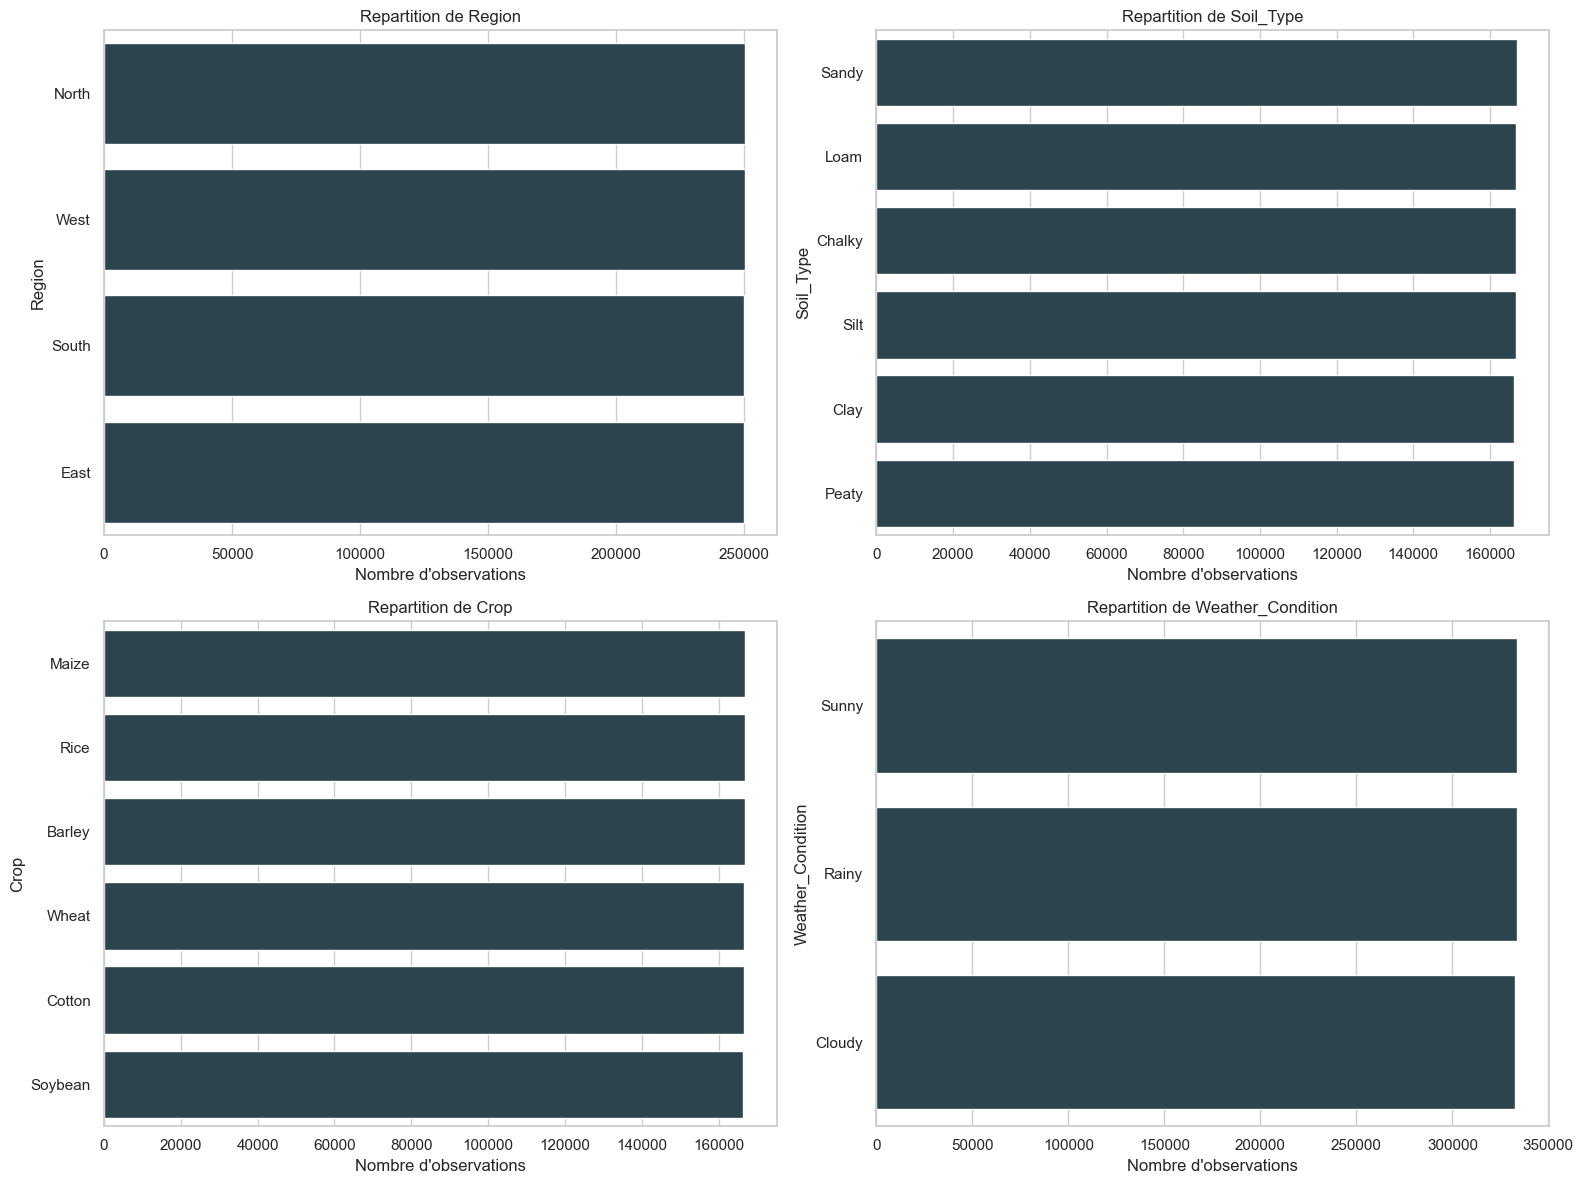

In [7]:
categorical_columns = ["Region", "Soil_Type", "Crop", "Weather_Condition"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, column in zip(axes.flat, categorical_columns):
    counts = data[column].value_counts().sort_values(ascending=False)
    sns.barplot(x=counts.values, y=counts.index, ax=ax, color="#264653")
    ax.set_title(f"Repartition de {column}")
    ax.set_xlabel("Nombre d'observations")
    ax.set_ylabel(column)

plt.tight_layout()
plt.show()


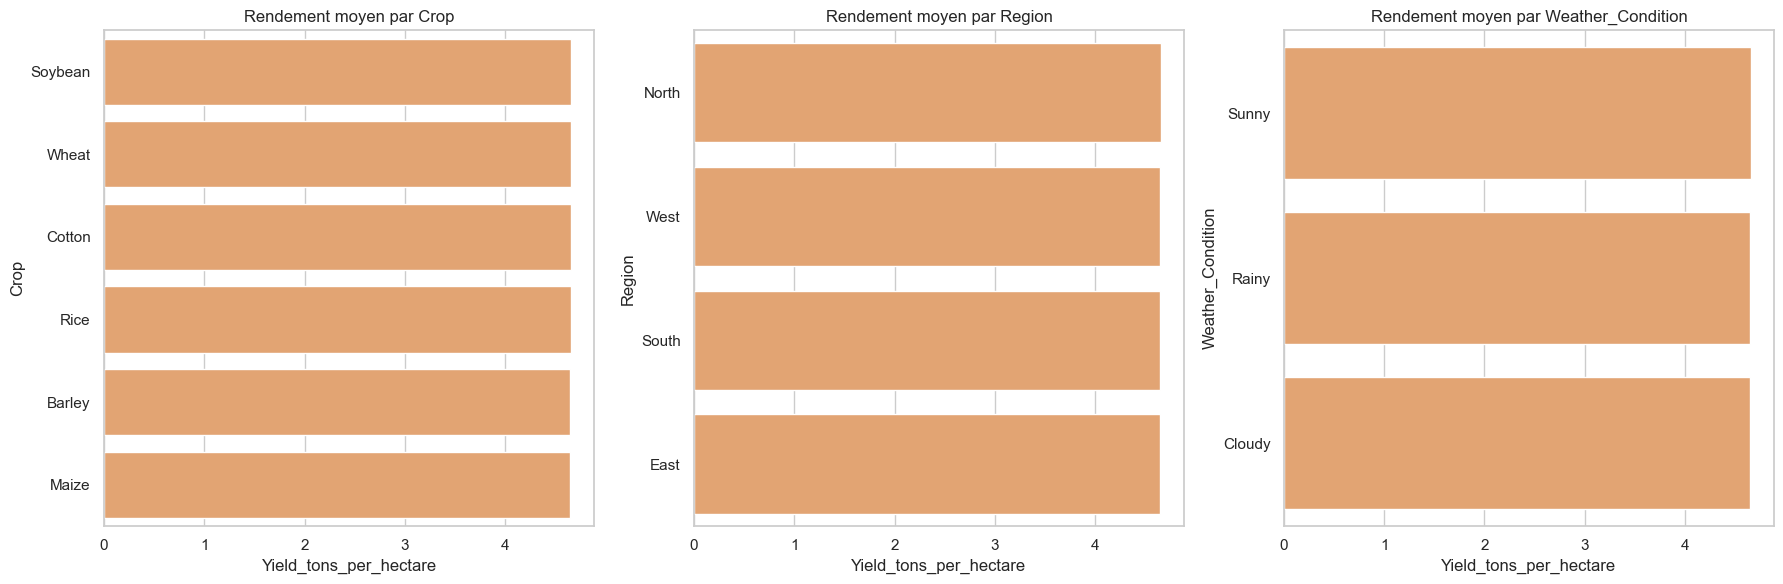

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, column in zip(axes, ["Crop", "Region", "Weather_Condition"]):
    mean_yield = data.groupby(column)["Yield_tons_per_hectare"].mean().sort_values(ascending=False)
    sns.barplot(x=mean_yield.values, y=mean_yield.index, ax=ax, color="#f4a261")
    ax.set_title(f"Rendement moyen par {column}")
    ax.set_xlabel("Yield_tons_per_hectare")
    ax.set_ylabel(column)

plt.tight_layout()
plt.show()


## Variables qui influencent le rendement

La matrice de corrélation et les nuages de points servent ici à repérer les facteurs les plus liés au rendement. Il ne s'agit pas encore d'un modèle prédictif, mais d'une lecture visuelle des relations les plus plausibles.


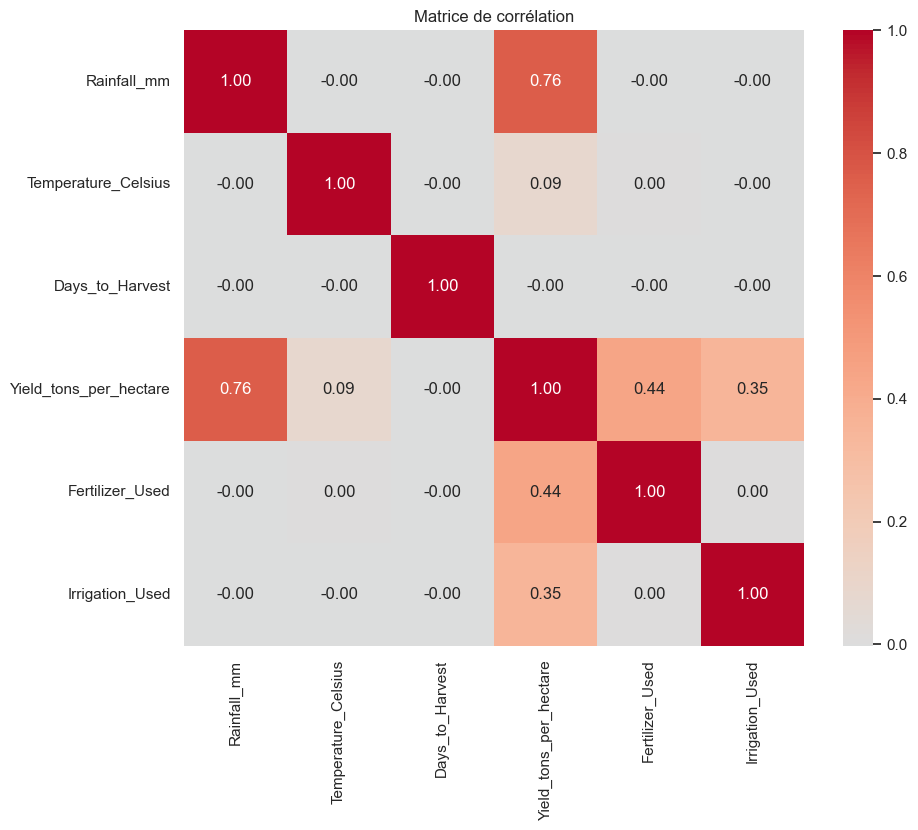

In [9]:
boolean_columns = ["Fertilizer_Used", "Irrigation_Used"]
corr_source = data[numeric_columns + boolean_columns].copy()

for column in boolean_columns:
    corr_source[column] = corr_source[column].astype(int)

corr_matrix = corr_source.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matrice de corrélation")
plt.show()


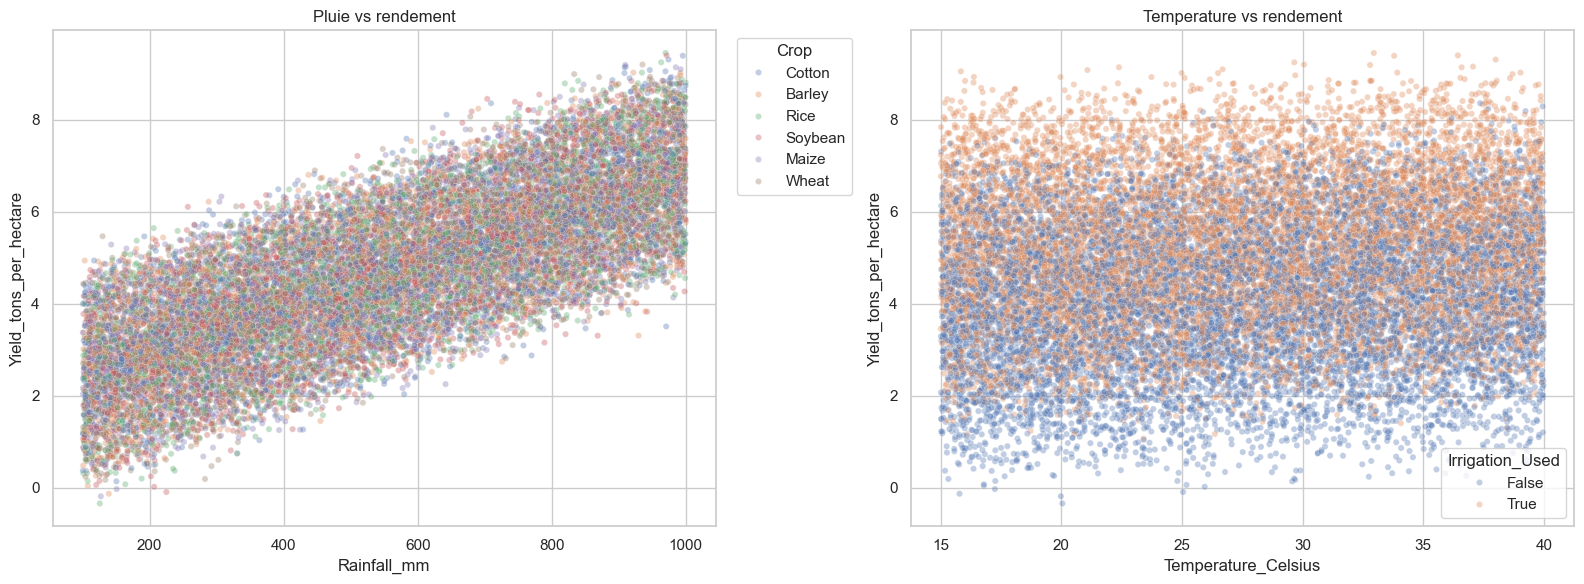

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=scatter_sample,
    x="Rainfall_mm",
    y="Yield_tons_per_hectare",
    hue="Crop",
    alpha=0.35,
    s=20,
    ax=axes[0],
)
axes[0].set_title("Pluie vs rendement")
axes[0].legend(title="Crop", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.scatterplot(
    data=scatter_sample,
    x="Temperature_Celsius",
    y="Yield_tons_per_hectare",
    hue="Irrigation_Used",
    alpha=0.35,
    s=20,
    ax=axes[1],
)
axes[1].set_title("Temperature vs rendement")
axes[1].legend(title="Irrigation_Used")

plt.tight_layout()
plt.show()


## Synthèse intermédiaire

À ce stade, les principaux constats à retenir sur `crop_yield.csv` sont les suivants :

- le dataset est propre sur les NaN et les doublons complets,
- les categories sont tres equilibrees, ce qui suggere un jeu de données probablement synthétique ou déjà très travaillé,
- quelques rendements négatifs ou extrêmes existent et devront etre arbitres avant la modélisation,
- les visualisations donnent une première lecture des liens potentiels avec le rendement.


## Lecture métier détaillée

Pour aller au-delà des graphiques, on ajoute des tableaux de synthèse qui permettent de commenter précisément les rendements moyens observés dans `crop_yield.csv`.

Point important : ce dataset ne contient pas une variable de surface en hectares. La mesure disponible est `Yield_tons_per_hectare`, donc un rendement déjà normalisé par hectare. On peut comparer l'effet de la pluie et de la température sur le rendement par hectare, mais pas mesurer l'effet de la taille des parcelles.


In [11]:
overall_table = pd.DataFrame(
    {
        "yield_moyen_t_ha": [round(data["Yield_tons_per_hectare"].mean(), 3)],
        "yield_median_t_ha": [round(data["Yield_tons_per_hectare"].median(), 3)],
        "yield_min_t_ha": [round(data["Yield_tons_per_hectare"].min(), 3)],
        "yield_max_t_ha": [round(data["Yield_tons_per_hectare"].max(), 3)],
    },
    index=["ensemble_du_dataset"],
)

crop_table = (
    data.groupby("Crop")["Yield_tons_per_hectare"]
    .agg(["mean", "median"])
    .rename(columns={"mean": "yield_moyen_t_ha", "median": "yield_median_t_ha"})
    .sort_values("yield_moyen_t_ha", ascending=False)
    .round(3)
)

rain_labels = ["Faible", "Moyenne-", "Moyenne+", "Forte"]
temp_labels = ["Fraiche", "Temperee-", "Temperee+", "Chaude"]
harvest_labels = ["Courte", "Moyenne-", "Moyenne+", "Longue"]

data["Rainfall_level"] = pd.qcut(data["Rainfall_mm"], q=4, labels=rain_labels, duplicates="drop")
data["Temperature_level"] = pd.qcut(data["Temperature_Celsius"], q=4, labels=temp_labels, duplicates="drop")
data["Harvest_level"] = pd.qcut(data["Days_to_Harvest"], q=4, labels=harvest_labels, duplicates="drop")

rain_table = (
    data.groupby("Rainfall_level", observed=False)["Yield_tons_per_hectare"]
    .agg(["count", "mean", "median"])
    .rename(columns={"count": "nb_lignes", "mean": "yield_moyen_t_ha", "median": "yield_median_t_ha"})
    .round(3)
)

temp_table = (
    data.groupby("Temperature_level", observed=False)["Yield_tons_per_hectare"]
    .agg(["count", "mean", "median"])
    .rename(columns={"count": "nb_lignes", "mean": "yield_moyen_t_ha", "median": "yield_median_t_ha"})
    .round(3)
)

harvest_table = (
    data.groupby("Harvest_level", observed=False)["Yield_tons_per_hectare"]
    .agg(["count", "mean", "median"])
    .rename(columns={"count": "nb_lignes", "mean": "yield_moyen_t_ha", "median": "yield_median_t_ha"})
    .round(3)
)

fertilizer_table = (
    data.groupby("Fertilizer_Used")["Yield_tons_per_hectare"]
    .agg(["count", "mean"])
    .rename(columns={"count": "nb_lignes", "mean": "yield_moyen_t_ha"})
    .round(3)
)

irrigation_table = (
    data.groupby("Irrigation_Used")["Yield_tons_per_hectare"]
    .agg(["count", "mean"])
    .rename(columns={"count": "nb_lignes", "mean": "yield_moyen_t_ha"})
    .round(3)
)

practice_table = (
    data.groupby(["Fertilizer_Used", "Irrigation_Used"])["Yield_tons_per_hectare"]
    .agg(["count", "mean"])
    .rename(columns={"count": "nb_lignes", "mean": "yield_moyen_t_ha"})
    .round(3)
)

rain_temp_table = (
    data.groupby(["Rainfall_level", "Temperature_level"], observed=False)["Yield_tons_per_hectare"]
    .mean()
    .unstack()
    .round(3)
)

display(overall_table)
display(crop_table)
display(rain_table)
display(temp_table)
display(harvest_table)
display(fertilizer_table)
display(irrigation_table)
display(practice_table)
display(rain_temp_table)


,yield_moyen_t_ha,yield_median_t_ha,yield_min_t_ha,yield_max_t_ha
ensemble_du_dataset,4.65,4.65,-1.15,9.96


,yield_moyen_t_ha,yield_median_t_ha
Crop,,
Soybean,4.65,4.66
Wheat,4.65,4.66
Cotton,4.65,4.65
Rice,4.65,4.65
Barley,4.65,4.65
Maize,4.64,4.64


,nb_lignes,yield_moyen_t_ha,yield_median_t_ha
Rainfall_level,,,
Faible,250000,2.96,2.96
Moyenne-,250000,4.09,4.09
Moyenne+,250000,5.21,5.21
Forte,250000,6.33,6.33


,nb_lignes,yield_moyen_t_ha,yield_median_t_ha
Temperature_level,,,
Fraiche,250000,4.46,4.45
Temperee-,250000,4.59,4.59
Temperee+,250000,4.71,4.71
Chaude,250000,4.84,4.84


,nb_lignes,yield_moyen_t_ha,yield_median_t_ha
Harvest_level,,,
Courte,255094,4.66,4.66
Moyenne-,244929,4.65,4.65
Moyenne+,256220,4.64,4.64
Longue,243757,4.65,4.66


,nb_lignes,yield_moyen_t_ha
Fertilizer_Used,,
False,500060,3.90
True,499940,5.40


,nb_lignes,yield_moyen_t_ha
Irrigation_Used,,
False,500509,4.05
True,499491,5.25


nb_lignes  yield_moyen_t_ha
Fertilizer_Used Irrigation_Used                             
False           False               250662              3.30
                True                249398              4.50
True            False               249847              4.80
                True                250093              6.00

Temperature_level,Fraiche,Temperee-,Temperee+,Chaude
Rainfall_level,,,,
Faible,2.77,2.90,3.03,3.15
Moyenne-,3.90,4.02,4.15,4.28
Moyenne+,5.02,5.15,5.28,5.41
Forte,6.15,6.28,6.38,6.52


### Explication des variables clés

Les tableaux ci-dessous décrivent `crop_yield.csv` et permettent de résumer les grandes relations visibles entre les variables agronomiques et le rendement.

Le rendement moyen global y est de **4,649 t/ha**, avec une médiane de **4,652 t/ha**. La distribution est donc assez centrée, même si quelques valeurs négatives et extrêmes existent.

L'effet le plus net vient de la pluie. Le quartile le plus sec, situé approximativement entre **100 et 325 mm**, atteint **2,963 t/ha** en moyenne. Le quartile le plus humide, entre **775 et 1 000 mm**, monte à **6,333 t/ha**. L'écart est donc d'environ **3,37 t/ha**, ce qui fait de la pluie la variable la plus structurante du dataset.

La température joue aussi dans le bon sens, mais plus modérément. On passe de **4,460 t/ha** dans le quartile le plus frais, autour de **15 à 21,3 °C**, à **4,840 t/ha** dans le quartile le plus chaud, autour de **33,8 à 40 °C**. L'effet existe, mais il reste beaucoup plus faible que celui de la pluie.

Le tableau croisé pluie x température montre bien cette hiérarchie. La situation la moins favorable est **faible pluie + température fraîche** avec **2,771 t/ha**, alors que la combinaison la plus favorable est **forte pluie + température chaude** avec **6,518 t/ha**. En pratique, la pluie domine la température dans l'explication des rendements.

Concernant les hectares, il faut être précis : **aucune variable de surface n'est présente** dans ce fichier. On ne peut donc pas comparer les rendements selon la taille des parcelles. La seule mesure disponible est déjà normalisée par hectare avec `Yield_tons_per_hectare`. Si l'on cherche une variable proche pour enrichir la lecture, `Days_to_Harvest` varie très peu selon les quartiles, avec des rendements moyens compris entre **4,640 et 4,657 t/ha**, ce qui suggère un effet faible.

Enfin, les écarts entre cultures restent faibles : de **4,641 t/ha** pour le maïs à **4,654 t/ha** pour le soja. En revanche, les pratiques agricoles marquent davantage le rendement moyen : **3,900 t/ha** sans fertilisant contre **5,400 t/ha** avec fertilisant, et **4,050 t/ha** sans irrigation contre **5,250 t/ha** avec irrigation. Le tableau croisé confirme cette logique : le rendement moyen le plus faible est observé sans fertilisant et sans irrigation (**3,300 t/ha**), et le plus élevé quand les deux sont activés (**6,000 t/ha**). Cela renforce l'idée d'un dataset très structuré, probablement synthétique, où certaines relations sont volontairement nettes.


## Lecture du jeu de données agronomiques et climatiques


## Vue d'ensemble des fichiers du dossier `Crop Yield Prediction Dataset`

Cette partie complète le rapport métier en décrivant le second jeu de données disponible dans la mission. L'objectif n'est pas d'implémenter ici la fusion, mais d'expliquer quelles sources sont fiables, quelles limites elles présentent et quels choix cela implique pour la suite du projet. La construction effective de la base consolidée est réservée à `modelisation.ipynb`.

Les fichiers étudiés sont : `yield.csv`, `yield_df.csv`, `rainfall.csv`, `pesticides.csv` et `temp.csv`.


In [12]:
from pathlib import Path

prediction_base = Path("data/Crop Yield Prediction Dataset")
prediction_datasets = {
    path.name: pd.read_csv(path)
    for path in sorted(prediction_base.glob("*.csv"))
}

prediction_overview_rows = []
for file_name, df in prediction_datasets.items():
    prediction_overview_rows.append(
        {
            "fichier": file_name,
            "nb_lignes": df.shape[0],
            "nb_colonnes": df.shape[1],
            "nan_total": int(df.isna().sum().sum()),
            "colonnes_avec_nan": int((df.isna().sum() > 0).sum()),
            "nb_colonnes_numeriques": int(df.select_dtypes(include=np.number).shape[1]),
            "nb_colonnes_non_numeriques": int(df.shape[1] - df.select_dtypes(include=np.number).shape[1]),
        }
    )

prediction_overview = pd.DataFrame(prediction_overview_rows).sort_values("fichier").reset_index(drop=True)
display(prediction_overview)


,fichier,nb_lignes,nb_colonnes,nan_total,colonnes_avec_nan,nb_colonnes_numeriques,nb_colonnes_non_numeriques
0,pesticides.csv,4349,7,0,0,2,5
1,rainfall.csv,6727,3,774,1,1,2
2,temp.csv,71311,3,2547,1,2,1
3,yield.csv,56717,12,0,0,6,6
4,yield_df.csv,28242,8,0,0,6,2


In [13]:
rainfall = prediction_datasets["rainfall.csv"].rename(columns={" Area": "Area"}).copy()
rainfall["average_rain_fall_mm_per_year_num"] = pd.to_numeric(
    rainfall["average_rain_fall_mm_per_year"], errors="coerce"
)
pesticides = prediction_datasets["pesticides.csv"].copy()
temp = prediction_datasets["temp.csv"].rename(columns={"country": "Area", "year": "Year"}).copy()
yield_raw = prediction_datasets["yield.csv"].copy()
yield_df = prediction_datasets["yield_df.csv"].copy()


## Visualisations de synthèse des fichiers

Avant d'entrer dans le détail, ces graphiques comparent le volume des fichiers, la quantité de valeurs manquantes et la structure des colonnes. Pour un lecteur métier, ils servent surtout à repérer quelles sources sont les plus solides et lesquelles demanderont plus de précautions avant d'alimenter un modèle.


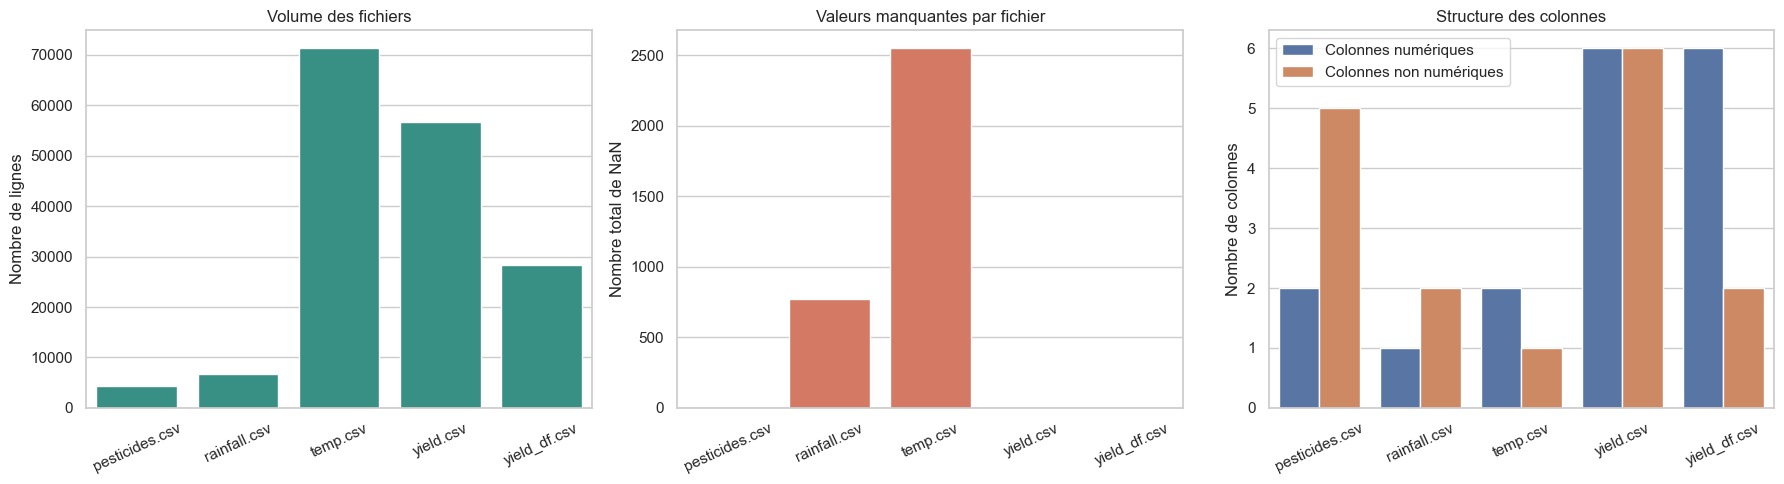

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=prediction_overview, x="fichier", y="nb_lignes", ax=axes[0], color="#2a9d8f")
axes[0].set_title("Volume des fichiers")
axes[0].set_xlabel("")
axes[0].set_ylabel("Nombre de lignes")
axes[0].tick_params(axis="x", rotation=25)

sns.barplot(data=prediction_overview, x="fichier", y="nan_total", ax=axes[1], color="#e76f51")
axes[1].set_title("Valeurs manquantes par fichier")
axes[1].set_xlabel("")
axes[1].set_ylabel("Nombre total de NaN")
axes[1].tick_params(axis="x", rotation=25)

structure_plot = prediction_overview.melt(
    id_vars="fichier",
    value_vars=["nb_colonnes_numeriques", "nb_colonnes_non_numeriques"],
    var_name="type_colonne",
    value_name="nombre_colonnes",
)
structure_plot["type_colonne"] = structure_plot["type_colonne"].map(
    {
        "nb_colonnes_numeriques": "Colonnes numériques",
        "nb_colonnes_non_numeriques": "Colonnes non numériques",
    }
)

sns.barplot(data=structure_plot, x="fichier", y="nombre_colonnes", hue="type_colonne", ax=axes[2])
axes[2].set_title("Structure des colonnes")
axes[2].set_xlabel("")
axes[2].set_ylabel("Nombre de colonnes")
axes[2].tick_params(axis="x", rotation=25)
axes[2].legend(title="")

plt.tight_layout()
plt.show()


## Couverture temporelle des fichiers

Les fichiers ne couvrent pas exactement les mêmes périodes ni les mêmes volumes d'observations par année. Cette lecture temporelle permet d'anticiper les années réellement communes entre les sources et d'évaluer la profondeur historique mobilisable pour construire la base d'entraînement.


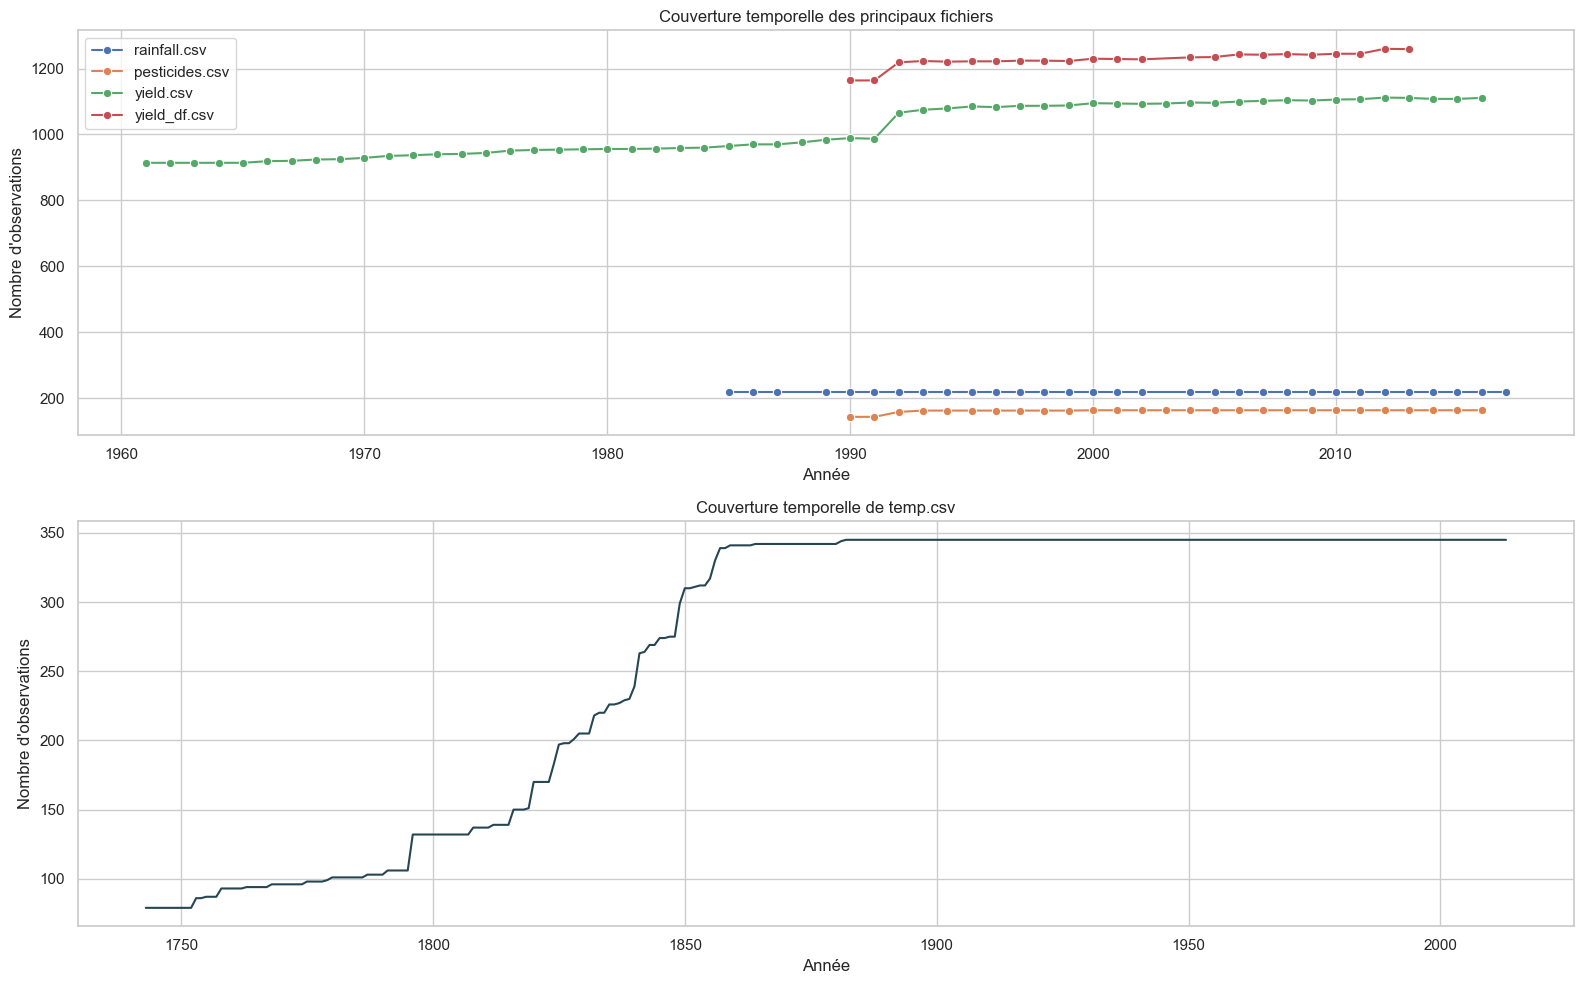

In [15]:
prediction_time_counts = pd.concat(
    [
        rainfall.groupby("Year").size().reset_index(name="nb_lignes").assign(fichier="rainfall.csv"),
        pesticides.groupby("Year").size().reset_index(name="nb_lignes").assign(fichier="pesticides.csv"),
        temp.groupby("Year").size().reset_index(name="nb_lignes").assign(fichier="temp.csv"),
        yield_raw.groupby("Year").size().reset_index(name="nb_lignes").assign(fichier="yield.csv"),
        yield_df.groupby("Year").size().reset_index(name="nb_lignes").assign(fichier="yield_df.csv"),
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=False)

main_files = prediction_time_counts[
    prediction_time_counts["fichier"].isin(["yield.csv", "yield_df.csv", "rainfall.csv", "pesticides.csv"])
]
sns.lineplot(data=main_files, x="Year", y="nb_lignes", hue="fichier", marker="o", ax=axes[0])
axes[0].set_title("Couverture temporelle des principaux fichiers")
axes[0].set_xlabel("Année")
axes[0].set_ylabel("Nombre d'observations")
axes[0].legend(title="")

sns.lineplot(
    data=prediction_time_counts[prediction_time_counts["fichier"] == "temp.csv"],
    x="Year",
    y="nb_lignes",
    color="#264653",
    ax=axes[1],
)
axes[1].set_title("Couverture temporelle de temp.csv")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Nombre d'observations")

plt.tight_layout()
plt.show()


## Colonnes, types de données et valeurs manquantes par fichier

Les tableaux ci-dessous détaillent, pour chaque CSV, les noms de colonnes, les types détectés, le nombre de valeurs manquantes et le nombre de modalités distinctes. Cette lecture répond à une question simple : quelles sources sont directement exploitables, et lesquelles demandent un travail de préparation avant d'être intégrées au pipeline ?


In [16]:
for file_name, df in prediction_datasets.items():
    print(f"\n===== {file_name} =====")
    schema = pd.DataFrame(
        {
            "colonne": df.columns,
            "dtype": df.dtypes.astype(str).values,
            "nb_nan": df.isna().sum().values,
            "pct_nan": (df.isna().mean() * 100).round(2).values,
            "nb_modalites": [df[column].nunique(dropna=False) for column in df.columns],
        }
    )
    display(schema)
    display(df.head(3))



===== pesticides.csv =====


,colonne,dtype,nb_nan,pct_nan,nb_modalites
0,Domain,object,0,0.00,1
1,Area,object,0,0.00,168
2,Element,object,0,0.00,1
3,Item,object,0,0.00,1
4,Year,int64,0,0.00,27
5,Unit,object,0,0.00,1
6,Value,float64,0,0.00,2825


,Domain,Area,Element,Item,Year,Unit,Value
0,Pesticides Use,Albania,Use,Pesticides (total),1990,tonnes of active ingredients,121.00
1,Pesticides Use,Albania,Use,Pesticides (total),1991,tonnes of active ingredients,121.00
2,Pesticides Use,Albania,Use,Pesticides (total),1992,tonnes of active ingredients,121.00



===== rainfall.csv =====


,colonne,dtype,nb_nan,pct_nan,nb_modalites
0,Area,object,0,0.00,217
1,Year,int64,0,0.00,31
2,average_rain_fall_mm_per_year,object,774,11.51,174


...

,colonne,dtype,nb_nan,pct_nan,nb_modalites
0,Domain Code,object,0,0.00,1
1,Domain,object,0,0.00,1
2,Area Code,int64,0,0.00,212
3,Area,object,0,0.00,212
4,Element Code,int64,0,0.00,1
5,Element,object,0,0.00,1
6,Item Code,int64,0,0.00,10
7,Item,object,0,0.00,10
8,Year Code,int64,0,0.00,56
9,Year,int64,0,0.00,56


,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1961,1961,hg/ha,14000
1,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1962,1962,hg/ha,14000
2,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1963,1963,hg/ha,14260



===== yield_df.csv =====


,colonne,dtype,nb_nan,pct_nan,nb_modalites
0,Unnamed: 0,int64,0,0.00,28242
1,Area,object,0,0.00,101
2,Item,object,0,0.00,10
3,Year,int64,0,0.00,23
4,hg/ha_yield,int64,0,0.00,11514
5,average_rain_fall_mm_per_year,float64,0,0.00,100
6,pesticides_tonnes,float64,0,0.00,1673
7,avg_temp,float64,0,0.00,1831


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,"1,485.00",121.00,16.37
1,1,Albania,Potatoes,1990,66667,"1,485.00",121.00,16.37
2,2,Albania,"Rice, paddy",1990,23333,"1,485.00",121.00,16.37


### Premiers constats sur les fichiers

- `yield.csv` est la source brute la plus riche pour le rendement : on y trouve la zone (`Area`), la culture (`Item`), l'année (`Year`) et la valeur de rendement (`Value`) sans valeur manquante.
- `rainfall.csv` est un petit fichier très utile pour la pluie annuelle, mais il contient une colonne ` Area` avec un espace initial et la variable `average_rain_fall_mm_per_year` est lue en texte, avec des valeurs manquantes codées sous la forme `..`.
- `pesticides.csv` est propre sur les valeurs manquantes et propose un indicateur d'usage de pesticides par zone et par année.
- `temp.csv` contient la température moyenne (`avg_temp`), mais avec des valeurs manquantes et surtout de très nombreux doublons sur `country + year`, ce qui impose une agrégation ou une règle de dédoublonnage avant toute jointure.
- `yield_df.csv` ressemble à un fichier déjà enrichi, sans valeurs manquantes, mais il ne doit pas être pris comme vérité finale : sa granularité n'est pas proprement unique sur `Area + Item + Year`.


## Focus visuel sur `yield.csv`

`yield.csv` est la source brute la plus structurante pour un futur travail de fusion, car elle porte la cible de rendement par zone, culture et année. Les graphiques suivants permettent d'en lire la répartition dans le temps, par culture et par intensité de rendement.


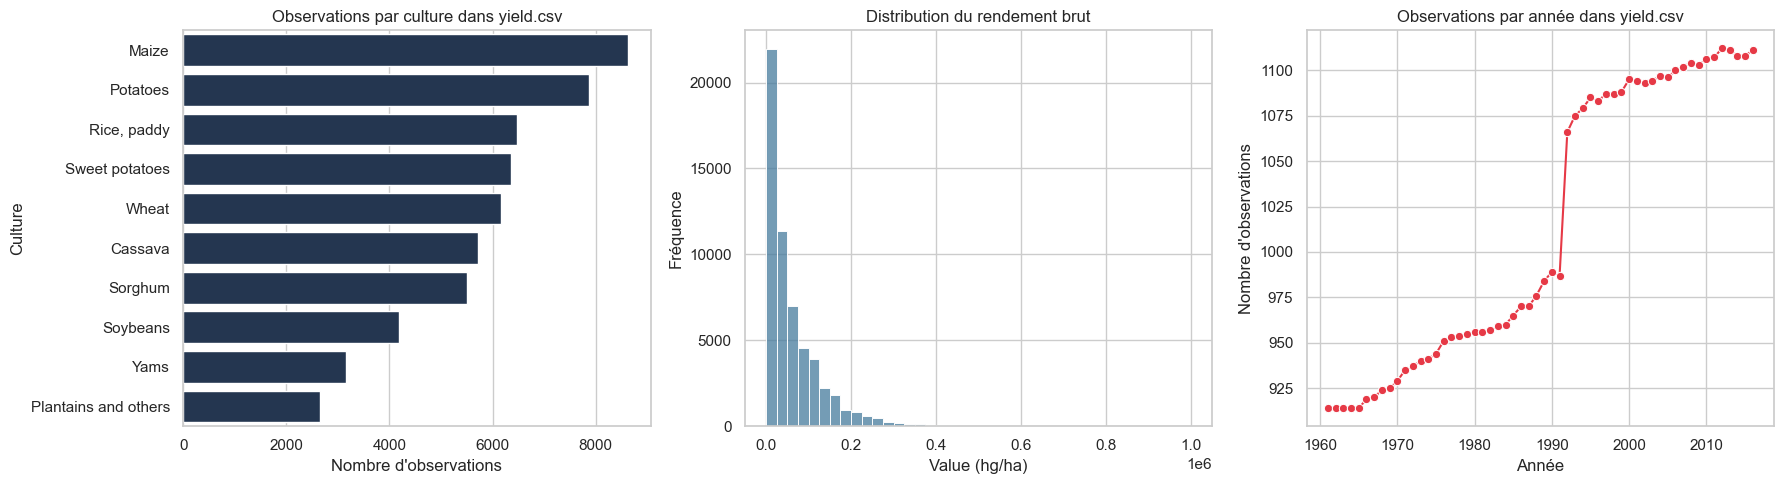

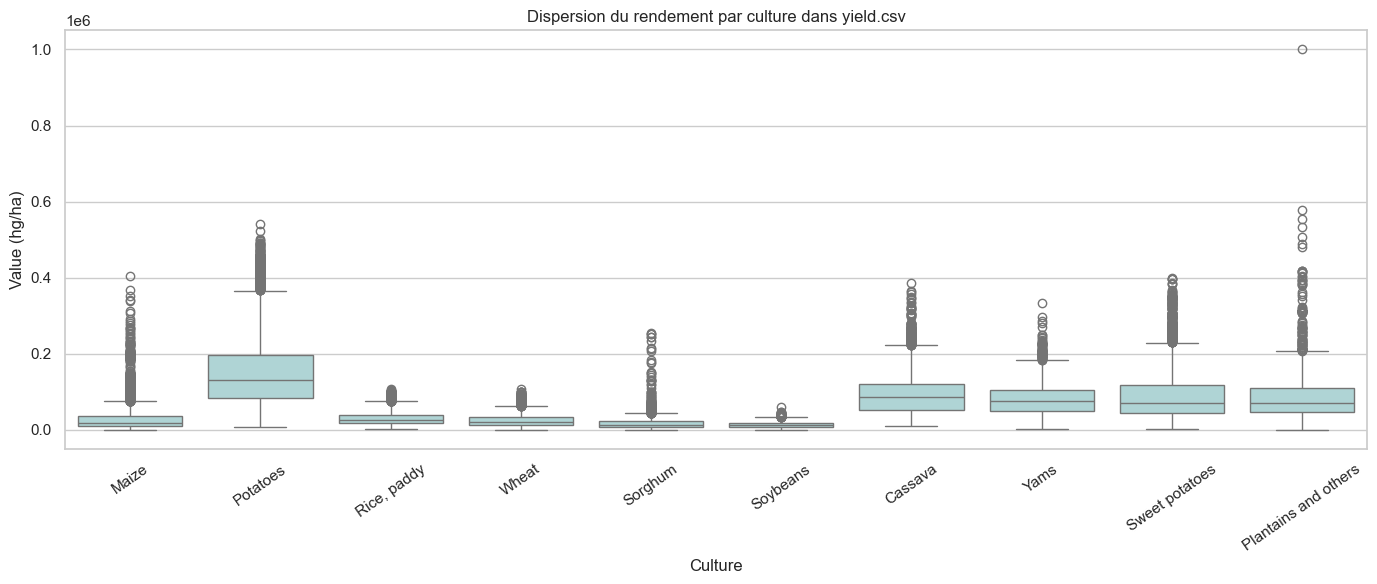

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

yield_item_counts = yield_raw["Item"].value_counts().sort_values(ascending=False).head(12)
sns.barplot(x=yield_item_counts.values, y=yield_item_counts.index, ax=axes[0], color="#1d3557")
axes[0].set_title("Observations par culture dans yield.csv")
axes[0].set_xlabel("Nombre d'observations")
axes[0].set_ylabel("Culture")

sns.histplot(data=yield_raw, x="Value", bins=40, ax=axes[1], color="#457b9d")
axes[1].set_title("Distribution du rendement brut")
axes[1].set_xlabel("Value (hg/ha)")
axes[1].set_ylabel("Fréquence")

yield_year_counts = yield_raw.groupby("Year").size().reset_index(name="nb_lignes")
sns.lineplot(data=yield_year_counts, x="Year", y="nb_lignes", marker="o", ax=axes[2], color="#e63946")
axes[2].set_title("Observations par année dans yield.csv")
axes[2].set_xlabel("Année")
axes[2].set_ylabel("Nombre d'observations")

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.boxplot(data=yield_raw, x="Item", y="Value", color="#a8dadc")
plt.title("Dispersion du rendement par culture dans yield.csv")
plt.xlabel("Culture")
plt.ylabel("Value (hg/ha)")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()


## Focus visuel sur `rainfall.csv` et `pesticides.csv`

Ces deux fichiers portent deux familles de variables explicatives futures : l'eau disponible à grande échelle et l'intensité d'usage des pesticides. Les visualisations servent ici à qualifier la qualité des données, l'ampleur des manquants et les grands ordres de grandeur observés.


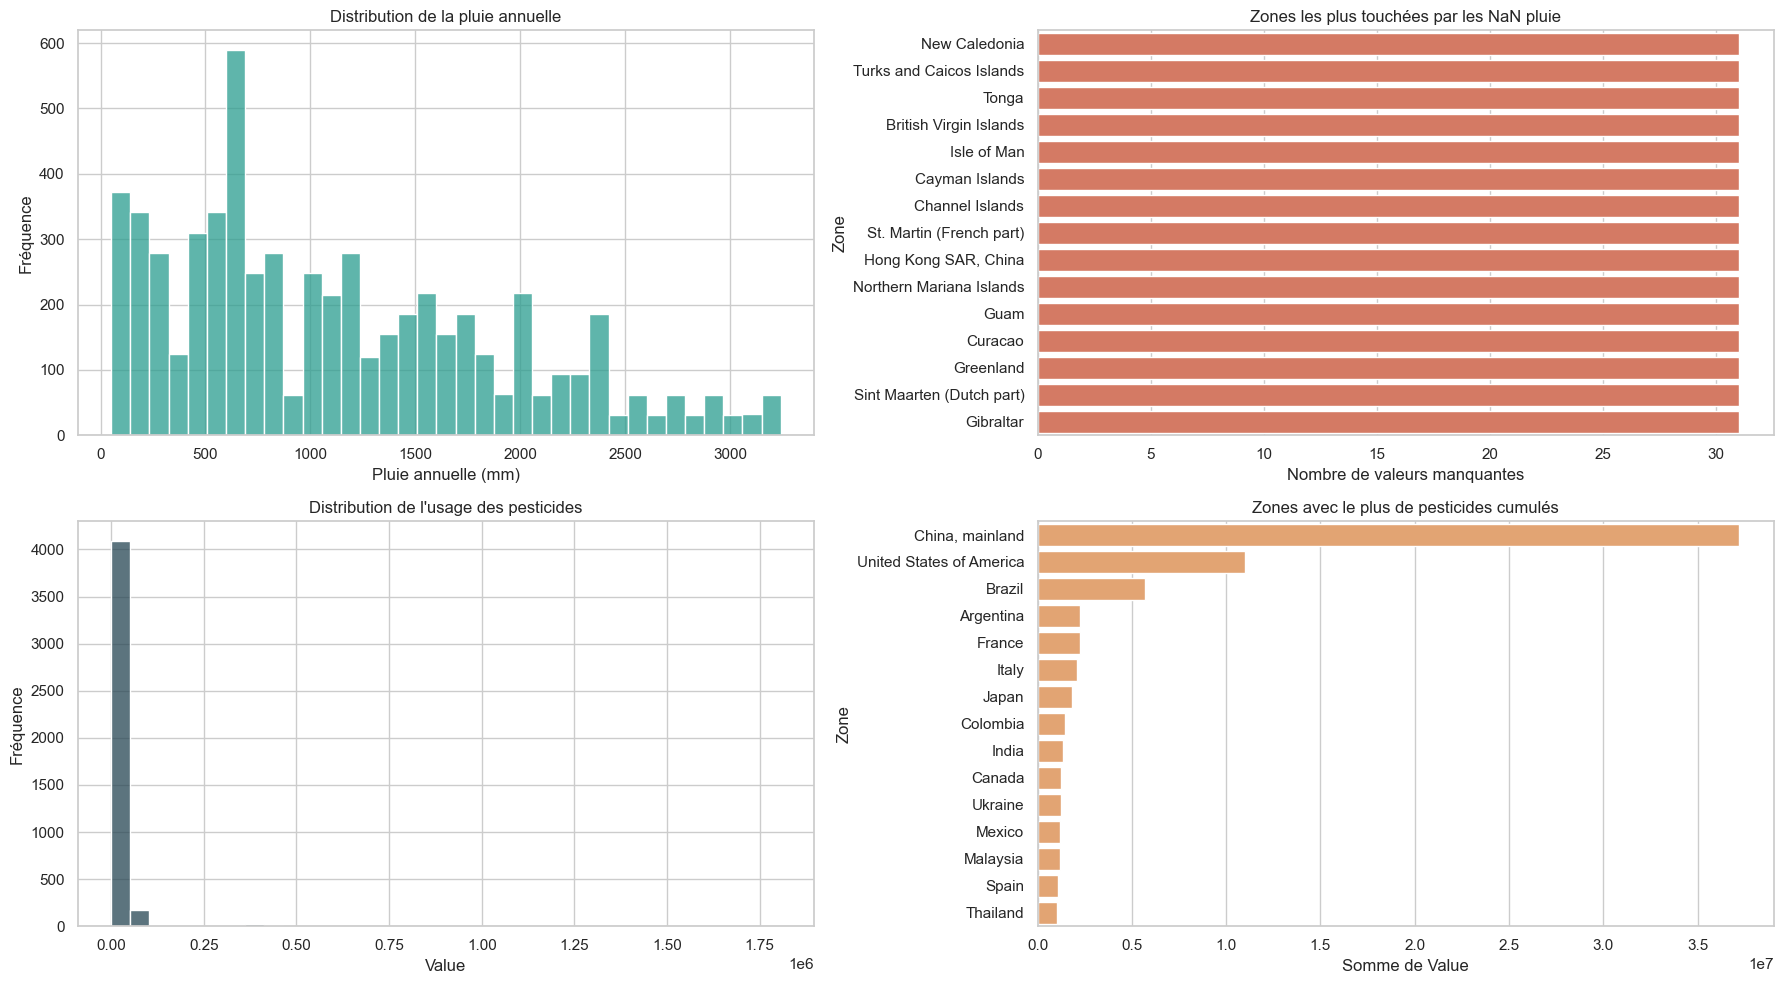

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

sns.histplot(data=rainfall, x="average_rain_fall_mm_per_year_num", bins=35, ax=axes[0, 0], color="#2a9d8f")
axes[0, 0].set_title("Distribution de la pluie annuelle")
axes[0, 0].set_xlabel("Pluie annuelle (mm)")
axes[0, 0].set_ylabel("Fréquence")

rain_missing_area = (
    rainfall.assign(is_missing=rainfall["average_rain_fall_mm_per_year_num"].isna())
    .groupby("Area")["is_missing"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name="nb_nan")
)
sns.barplot(data=rain_missing_area, x="nb_nan", y="Area", ax=axes[0, 1], color="#e76f51")
axes[0, 1].set_title("Zones les plus touchées par les NaN pluie")
axes[0, 1].set_xlabel("Nombre de valeurs manquantes")
axes[0, 1].set_ylabel("Zone")

sns.histplot(data=pesticides, x="Value", bins=35, ax=axes[1, 0], color="#264653")
axes[1, 0].set_title("Distribution de l'usage des pesticides")
axes[1, 0].set_xlabel("Value")
axes[1, 0].set_ylabel("Fréquence")

pesticides_top_areas = (
    pesticides.groupby("Area")["Value"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
sns.barplot(data=pesticides_top_areas, x="Value", y="Area", ax=axes[1, 1], color="#f4a261")
axes[1, 1].set_title("Zones avec le plus de pesticides cumulés")
axes[1, 1].set_xlabel("Somme de Value")
axes[1, 1].set_ylabel("Zone")

plt.tight_layout()
plt.show()


## Focus visuel sur `temp.csv` et `yield_df.csv`

`temp.csv` apporte le contexte thermique, mais sa qualité doit être contrôlée à cause des doublons. `yield_df.csv` ressemble à une table déjà enrichie ; on l'explore ici pour comprendre sa structure, ses distributions et les risques qu'elle présente avant toute utilisation plus poussée.


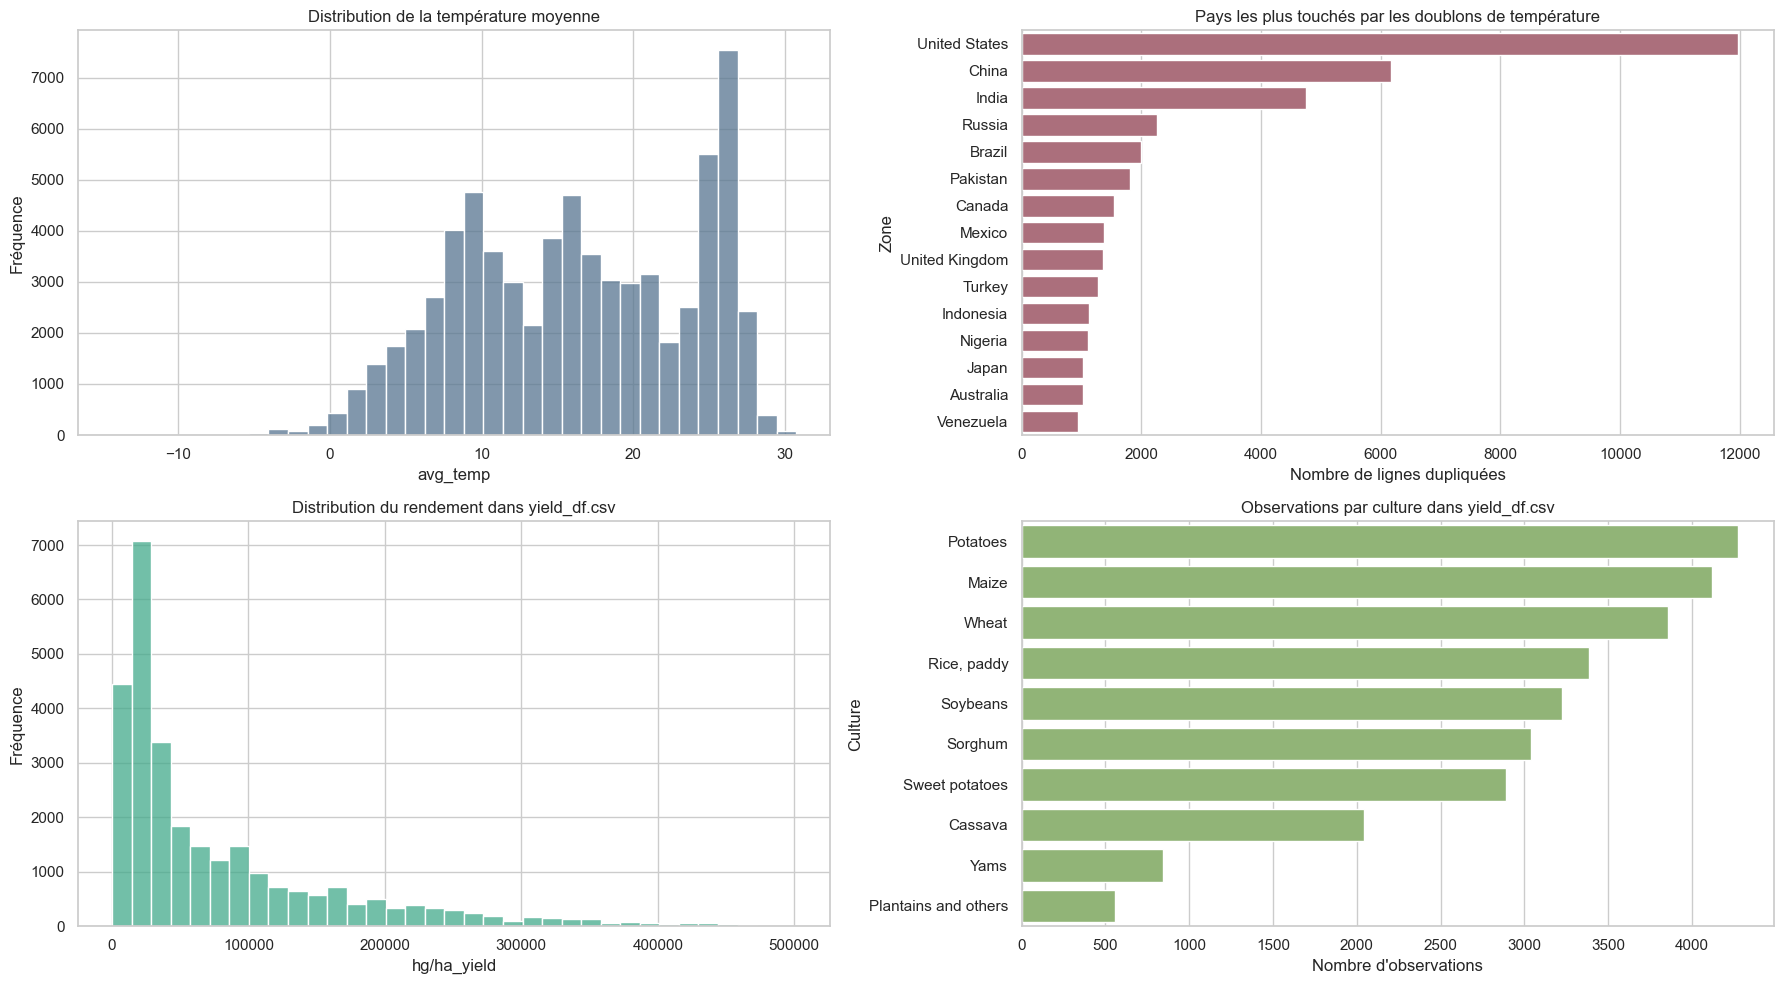

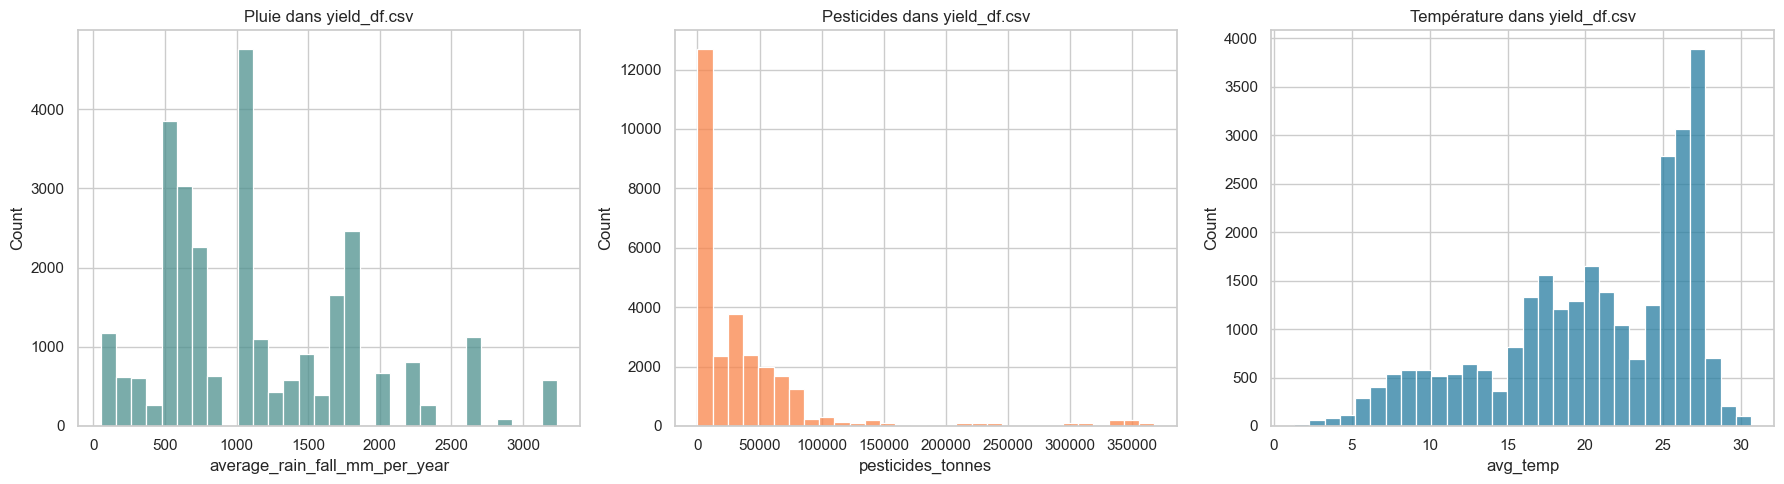

In [19]:
temp_duplicate_areas = (
    temp[temp.duplicated(subset=["Area", "Year"], keep=False)]
    .groupby("Area")
    .size()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name="nb_lignes_dupliquees")
)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

sns.histplot(data=temp, x="avg_temp", bins=35, ax=axes[0, 0], color="#577590")
axes[0, 0].set_title("Distribution de la température moyenne")
axes[0, 0].set_xlabel("avg_temp")
axes[0, 0].set_ylabel("Fréquence")

sns.barplot(data=temp_duplicate_areas, x="nb_lignes_dupliquees", y="Area", ax=axes[0, 1], color="#b56576")
axes[0, 1].set_title("Pays les plus touchés par les doublons de température")
axes[0, 1].set_xlabel("Nombre de lignes dupliquées")
axes[0, 1].set_ylabel("Zone")

sns.histplot(data=yield_df, x="hg/ha_yield", bins=35, ax=axes[1, 0], color="#43aa8b")
axes[1, 0].set_title("Distribution du rendement dans yield_df.csv")
axes[1, 0].set_xlabel("hg/ha_yield")
axes[1, 0].set_ylabel("Fréquence")

yield_df_item_counts = yield_df["Item"].value_counts().sort_values(ascending=False).head(12)
sns.barplot(x=yield_df_item_counts.values, y=yield_df_item_counts.index, ax=axes[1, 1], color="#90be6d")
axes[1, 1].set_title("Observations par culture dans yield_df.csv")
axes[1, 1].set_xlabel("Nombre d'observations")
axes[1, 1].set_ylabel("Culture")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=yield_df, x="average_rain_fall_mm_per_year", bins=30, ax=axes[0], color="#4d908e")
axes[0].set_title("Pluie dans yield_df.csv")
axes[0].set_xlabel("average_rain_fall_mm_per_year")

sns.histplot(data=yield_df, x="pesticides_tonnes", bins=30, ax=axes[1], color="#f9844a")
axes[1].set_title("Pesticides dans yield_df.csv")
axes[1].set_xlabel("pesticides_tonnes")

sns.histplot(data=yield_df, x="avg_temp", bins=30, ax=axes[2], color="#277da1")
axes[2].set_title("Température dans yield_df.csv")
axes[2].set_xlabel("avg_temp")

plt.tight_layout()
plt.show()


## Choix retenus pour structurer les données

Avant toute fusion, il faut identifier la granularité de chaque fichier et vérifier quelles clés de jointure semblent plausibles. Ici, le but est de documenter le raisonnement métier et technique qui guidera ensuite la construction du dataset dans `modelisation.ipynb`.


In [20]:
rainfall = prediction_datasets["rainfall.csv"].rename(columns={" Area": "Area"}).copy()
rainfall["average_rain_fall_mm_per_year_num"] = pd.to_numeric(
    rainfall["average_rain_fall_mm_per_year"], errors="coerce"
)
pesticides = prediction_datasets["pesticides.csv"].copy()
temp = prediction_datasets["temp.csv"].rename(columns={"country": "Area", "year": "Year"}).copy()
yield_raw = prediction_datasets["yield.csv"].copy()
yield_df = prediction_datasets["yield_df.csv"].copy()

join_key_table = pd.DataFrame(
    [
        {
            "fichier": "rainfall.csv",
            "granularite_observee": "Area + Year",
            "cle_potentielle": "Area + Year",
            "doublons_sur_cle": int(rainfall.duplicated(subset=["Area", "Year"]).sum()),
            "commentaire": "clé exploitable après renommage de ` Area` et conversion de la pluie en numérique",
        },
        {
            "fichier": "pesticides.csv",
            "granularite_observee": "Area + Year",
            "cle_potentielle": "Area + Year",
            "doublons_sur_cle": int(pesticides.duplicated(subset=["Area", "Year"]).sum()),
            "commentaire": "clé exploitable telle quelle",
        },
        {
            "fichier": "temp.csv",
            "granularite_observee": "country + year",
            "cle_potentielle": "Area + Year après renommage",
            "doublons_sur_cle": int(temp.duplicated(subset=["Area", "Year"]).sum()),
            "commentaire": "clé non exploitable en l'état à cause des doublons pays-année",
        },
        {
            "fichier": "yield.csv",
            "granularite_observee": "Area + Item + Year",
            "cle_potentielle": "Area + Item + Year",
            "doublons_sur_cle": int(yield_raw.duplicated(subset=["Area", "Item", "Year"]).sum()),
            "commentaire": "bonne table de base pour un futur dataset fusionné",
        },
        {
            "fichier": "yield_df.csv",
            "granularite_observee": "Area + Item + Year",
            "cle_potentielle": "Area + Item + Year",
            "doublons_sur_cle": int(yield_df.duplicated(subset=["Area", "Item", "Year"]).sum()),
            "commentaire": "fichier enrichi utile pour audit, mais non unique sur la clé métier attendue",
        },
    ]
)

yield_area_year = yield_raw[["Area", "Year"]].drop_duplicates()
yield_df_area_year = yield_df[["Area", "Year"]].drop_duplicates()

join_overlap_table = pd.DataFrame(
    [
        {
            "comparaison": "yield.csv vs rainfall.csv sur Area + Year",
            "cles_communes": yield_area_year.merge(rainfall[["Area", "Year"]].drop_duplicates(), on=["Area", "Year"], how="inner").shape[0],
            "cles_de_reference": yield_area_year.shape[0],
        },
        {
            "comparaison": "yield.csv vs pesticides.csv sur Area + Year",
            "cles_communes": yield_area_year.merge(pesticides[["Area", "Year"]].drop_duplicates(), on=["Area", "Year"], how="inner").shape[0],
            "cles_de_reference": yield_area_year.shape[0],
        },
        {
            "comparaison": "yield.csv vs temp.csv sur Area + Year",
            "cles_communes": yield_area_year.merge(temp[["Area", "Year"]].drop_duplicates(), on=["Area", "Year"], how="inner").shape[0],
            "cles_de_reference": yield_area_year.shape[0],
        },
        {
            "comparaison": "yield_df.csv vs rainfall.csv sur Area + Year",
            "cles_communes": yield_df_area_year.merge(rainfall[["Area", "Year"]].drop_duplicates(), on=["Area", "Year"], how="inner").shape[0],
            "cles_de_reference": yield_df_area_year.shape[0],
        },
        {
            "comparaison": "yield_df.csv vs pesticides.csv sur Area + Year",
            "cles_communes": yield_df_area_year.merge(pesticides[["Area", "Year"]].drop_duplicates(), on=["Area", "Year"], how="inner").shape[0],
            "cles_de_reference": yield_df_area_year.shape[0],
        },
        {
            "comparaison": "yield_df.csv vs temp.csv sur Area + Year",
            "cles_communes": yield_df_area_year.merge(temp[["Area", "Year"]].drop_duplicates(), on=["Area", "Year"], how="inner").shape[0],
            "cles_de_reference": yield_df_area_year.shape[0],
        },
        {
            "comparaison": "yield_df.csv vs yield.csv sur Area + Item + Year",
            "cles_communes": yield_df[["Area", "Item", "Year"]].drop_duplicates().merge(yield_raw[["Area", "Item", "Year"]].drop_duplicates(), on=["Area", "Item", "Year"], how="inner").shape[0],
            "cles_de_reference": yield_df[["Area", "Item", "Year"]].drop_duplicates().shape[0],
        },
    ]
)
join_overlap_table["taux_couverture_pct"] = (
    join_overlap_table["cles_communes"] / join_overlap_table["cles_de_reference"] * 100
).round(2)

proxy_table = pd.DataFrame(
    [
        {
            "besoin_metier": "Irrigation",
            "variable_proxy": "average_rain_fall_mm_per_year",
            "fichiers": "rainfall.csv, yield_df.csv",
            "lecture_metier": "proxy indirect de disponibilité en eau, pas une mesure réelle d'irrigation",
        },
        {
            "besoin_metier": "Fertilisation",
            "variable_proxy": "Value / pesticides_tonnes",
            "fichiers": "pesticides.csv, yield_df.csv",
            "lecture_metier": "proxy très imparfait d'intensité d'intrants chimiques ; mesure les pesticides et non les engrais",
        },
        {
            "besoin_metier": "Contexte climatique",
            "variable_proxy": "avg_temp",
            "fichiers": "temp.csv, yield_df.csv",
            "lecture_metier": "variable climatique complémentaire utile pour expliquer le rendement",
        },
    ]
)

display(join_key_table)
display(join_overlap_table)
display(proxy_table)


,fichier,granularite_observee,cle_potentielle,doublons_sur_cle,commentaire
0,rainfall.csv,Area + Year,Area + Year,0,clé exploitable après renommage de ` Area` et ...
1,pesticides.csv,Area + Year,Area + Year,0,clé exploitable telle quelle
2,temp.csv,country + year,Area + Year après renommage,42797,clé non exploitable en l'état à cause des doub...
3,yield.csv,Area + Item + Year,Area + Item + Year,0,bonne table de base pour un futur dataset fusi...
4,yield_df.csv,Area + Item + Year,Area + Item + Year,15112,"fichier enrichi utile pour audit, mais non uni..."


,comparaison,cles_communes,cles_de_reference,taux_couverture_pct
0,yield.csv vs rainfall.csv sur Area + Year,4847,10572,45.85
1,yield.csv vs pesticides.csv sur Area + Year,4318,10572,40.84
2,yield.csv vs temp.csv sur Area + Year,5580,10572,52.78
3,yield_df.csv vs rainfall.csv sur Area + Year,2250,2250,100.00
4,yield_df.csv vs pesticides.csv sur Area + Year,2250,2250,100.00
5,yield_df.csv vs temp.csv sur Area + Year,2250,2250,100.00
6,yield_df.csv vs yield.csv sur Area + Item + Year,13130,13130,100.00


,besoin_metier,variable_proxy,fichiers,lecture_metier
0,Irrigation,average_rain_fall_mm_per_year,"rainfall.csv, yield_df.csv","proxy indirect de disponibilité en eau, pas un..."
1,Fertilisation,Value / pesticides_tonnes,"pesticides.csv, yield_df.csv",proxy très imparfait d'intensité d'intrants ch...
2,Contexte climatique,avg_temp,"temp.csv, yield_df.csv",variable climatique complémentaire utile pour ...


## Visualisations des clés de jointure et des proxies

Ces graphiques traduisent visuellement les deux questions les plus importantes pour la suite : quelles tables sont propres sur leur clé potentielle, et dans quelle mesure les recouvrements entre fichiers sont suffisants pour construire une base enrichie sans perdre trop d'information.


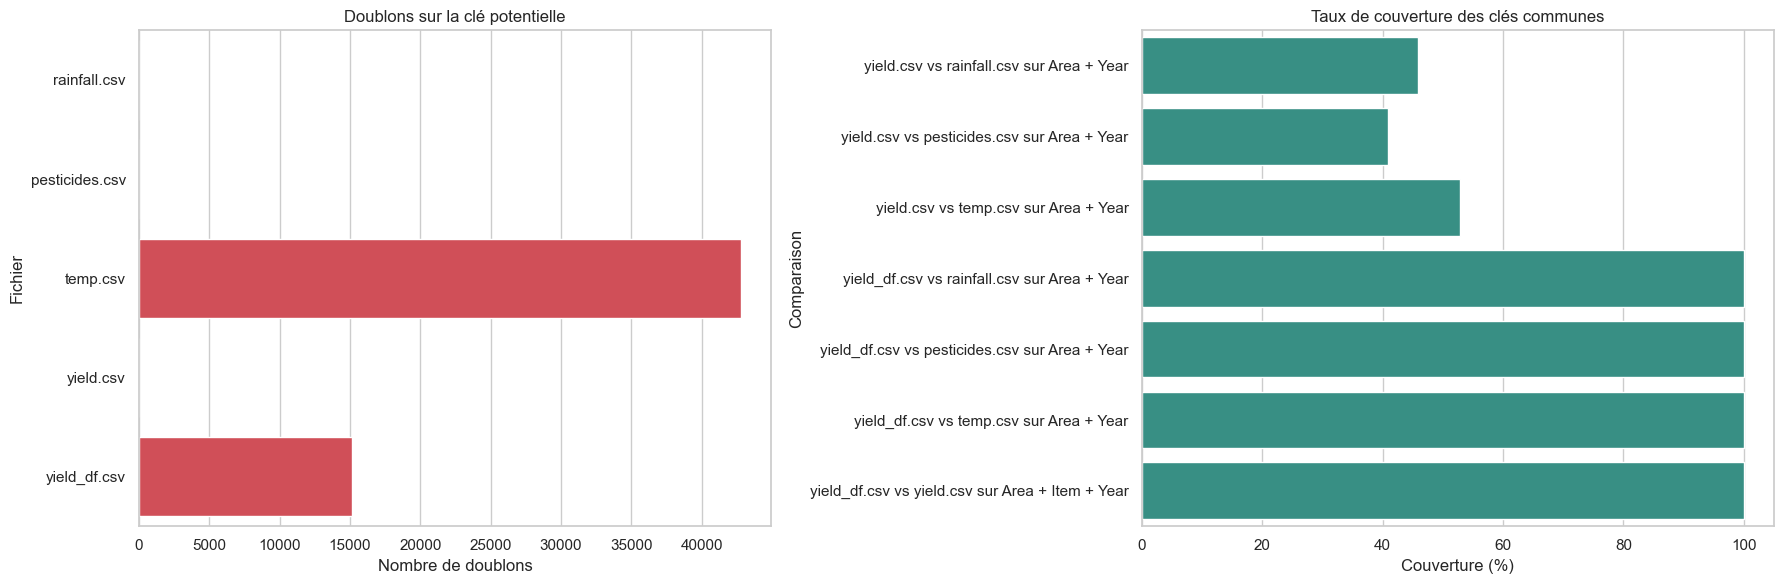

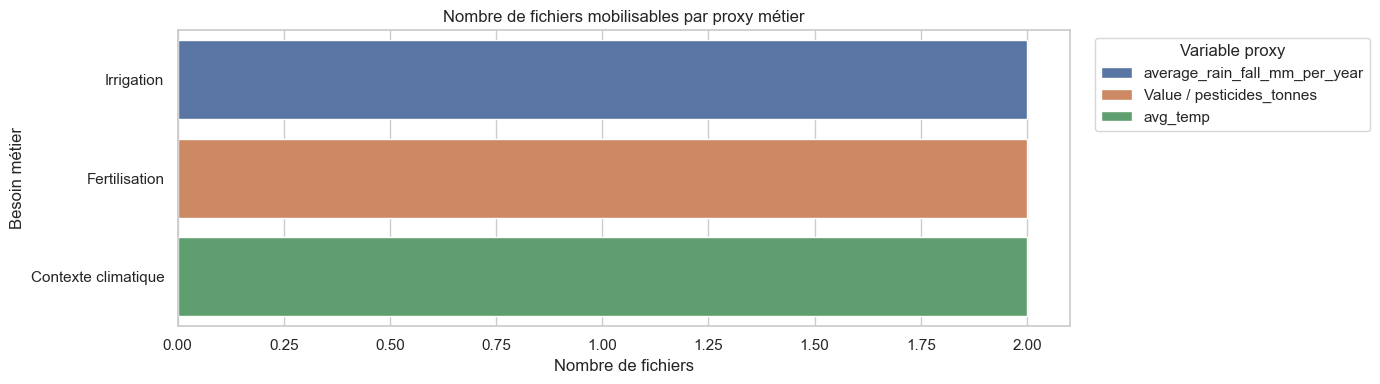

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=join_key_table, x="doublons_sur_cle", y="fichier", ax=axes[0], color="#e63946")
axes[0].set_title("Doublons sur la clé potentielle")
axes[0].set_xlabel("Nombre de doublons")
axes[0].set_ylabel("Fichier")

sns.barplot(data=join_overlap_table, x="taux_couverture_pct", y="comparaison", ax=axes[1], color="#2a9d8f")
axes[1].set_title("Taux de couverture des clés communes")
axes[1].set_xlabel("Couverture (%)")
axes[1].set_ylabel("Comparaison")

plt.tight_layout()
plt.show()

proxy_plot = proxy_table.assign(nb_fichiers=proxy_table["fichiers"].str.count(",") + 1)
plt.figure(figsize=(14, 4))
sns.barplot(data=proxy_plot, x="nb_fichiers", y="besoin_metier", hue="variable_proxy")
plt.title("Nombre de fichiers mobilisables par proxy métier")
plt.xlabel("Nombre de fichiers")
plt.ylabel("Besoin métier")
plt.legend(title="Variable proxy", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Choix de jointure et variables proxy retenus

Les fichiers `rainfall.csv` et `pesticides.csv` sont les plus simples à raccorder à un futur dataset fusionné : leur granularité naturelle est `Area + Year`, sans doublon sur cette clé.

Le fichier `yield.csv` est le meilleur candidat pour servir de table de base, car il porte la cible de rendement avec une granularité plus fine, `Area + Item + Year`, sans doublon sur cette clé. La logique retenue pour la suite consiste donc à ajouter les variables climatiques et d'intrants à partir de `Area + Year`.

Le fichier `temp.csv` demande en revanche un vrai prétraitement avant jointure : il faut harmoniser `country` en `Area`, puis traiter les nombreux doublons `country + year` avant d'en faire une source de température fiable.

Le fichier `yield_df.csv` doit être lu comme un fichier déjà enrichi, utile pour audit ou contrôle, mais pas comme une source brute propre de départ. Le fait qu'il ne soit pas unique sur `Area + Item + Year` impose de le traiter avec prudence.

Enfin, sur les proxies métier, il faut rester précis :

- `average_rain_fall_mm_per_year` peut jouer le rôle de proxy indirect de disponibilité en eau, mais pas d'irrigation réelle ;
- `pesticides_tonnes` peut servir de proxy très imparfait de niveau d'intrants chimiques, mais pas de fertilisation à proprement parler ;
- `avg_temp` complète la lecture du contexte climatique, sans représenter un intrant agricole.

Ces choix sont expliqués ici dans le rapport ; leur mise en oeuvre opérationnelle est effectuée dans `modelisation.ipynb`.


## Choix de préparation du dataset `Agriculture CropYield`


Cette partie résume les choix de préparation retenus sur `crop_yield.csv`, qui correspond ici au dataset **Agriculture CropYield**. L'objectif est d'expliquer, dans le rapport, comment le jeu de données a été fiabilisé avant l'ACP et avant la modélisation.

Les opérations détaillées ne sont pas l'objet du rapport métier : on documente ici leur logique, leurs impacts et leurs limites. La préparation opérationnelle utilisée pour la suite du projet est portée par `modelisation.ipynb`.


In [22]:
agriculture_crop_yield_raw = data.copy()

agri_raw_memory_mb = agriculture_crop_yield_raw.memory_usage(deep=True).sum() / 1024**2
agri_raw_audit = pd.DataFrame(
    {
        'indicateur': [
            'nb_lignes',
            'nb_colonnes',
            'valeurs_manquantes',
            'doublons_lignes',
            'doublons_colonnes',
            'rendements_negatifs',
            'outliers_iqr_rendement',
            'memoire_mb',
        ],
        'valeur': [
            agriculture_crop_yield_raw.shape[0],
            agriculture_crop_yield_raw.shape[1],
            int(agriculture_crop_yield_raw.isna().sum().sum()),
            int(agriculture_crop_yield_raw.duplicated().sum()),
            int(pd.Index(agriculture_crop_yield_raw.columns).duplicated().sum()),
            int((agriculture_crop_yield_raw['Yield_tons_per_hectare'] < 0).sum()),
            int(
                (
                    (agriculture_crop_yield_raw['Yield_tons_per_hectare'] < -0.2747065595393381)
                    | (agriculture_crop_yield_raw['Yield_tons_per_hectare'] > 9.571544091149985)
                ).sum()
            ),
            round(agri_raw_memory_mb, 2),
        ],
    }
)
display(agri_raw_audit)


,indicateur,valeur
0,nb_lignes,"1,000,000.00"
1,nb_colonnes,13.00
2,valeurs_manquantes,0.00
3,doublons_lignes,0.00
4,doublons_colonnes,0.00
5,rendements_negatifs,231.00
6,outliers_iqr_rendement,84.00
7,memoire_mb,241.28


## Choix de préparation retenus

Les décisions ci-dessous cherchent à rester sobres et défendables : on corrige ce qui gênerait l'analyse ou la suite du projet, sans transformer artificiellement le dataset.

- aucune imputation n'est nécessaire, car le fichier ne contient pas de valeur manquante ;
- aucune suppression de doublon n'est réalisée, car aucun doublon complet n'est détecté ;
- les noms de colonnes sont harmonisés en `snake_case` pour faciliter les manipulations et garder une convention homogène dans le projet ;
- les variables textuelles sont nettoyées par simple suppression d'espaces parasites, puis converties en `category` pour mieux refléter leur faible cardinalité ;
- les colonnes booléennes sont conservées comme booléens, car elles portent déjà une information métier propre et lisible ;
- les rendements négatifs sont retirés, car ils sont incohérents avec l'interprétation métier d'un rendement agricole ;
- les valeurs élevées mais positives ne sont pas supprimées ici : elles seront réévaluées plus tard dans la modélisation, afin d'éviter un nettoyage trop agressif.


In [23]:
agriculture_crop_yield_clean = agriculture_crop_yield_raw.copy().rename(
    columns={
        'Region': 'region',
        'Soil_Type': 'soil_type',
        'Crop': 'crop',
        'Rainfall_mm': 'rainfall_mm',
        'Temperature_Celsius': 'temperature_celsius',
        'Fertilizer_Used': 'fertilizer_used',
        'Irrigation_Used': 'irrigation_used',
        'Weather_Condition': 'weather_condition',
        'Days_to_Harvest': 'days_to_harvest',
        'Yield_tons_per_hectare': 'yield_tons_per_hectare',
    }
)

categorical_cols = ['region', 'soil_type', 'crop', 'weather_condition']
numeric_cols = ['rainfall_mm', 'temperature_celsius', 'days_to_harvest', 'yield_tons_per_hectare']

agriculture_crop_yield_clean[categorical_cols] = agriculture_crop_yield_clean[categorical_cols].apply(
    lambda col: col.astype(str).str.strip()
)
agriculture_crop_yield_clean[numeric_cols] = agriculture_crop_yield_clean[numeric_cols].apply(
    pd.to_numeric, errors='coerce'
)

for col in categorical_cols:
    agriculture_crop_yield_clean[col] = agriculture_crop_yield_clean[col].astype('category')

agriculture_crop_yield_clean['fertilizer_used'] = agriculture_crop_yield_clean['fertilizer_used'].astype(bool)
agriculture_crop_yield_clean['irrigation_used'] = agriculture_crop_yield_clean['irrigation_used'].astype(bool)

nb_negative_removed = int((agriculture_crop_yield_clean['yield_tons_per_hectare'] < 0).sum())
agriculture_crop_yield_clean = agriculture_crop_yield_clean.loc[
    agriculture_crop_yield_clean['yield_tons_per_hectare'] >= 0
].reset_index(drop=True)

agri_cleaning_log = pd.DataFrame(
    [
        {
            'operation': 'Renommage des colonnes en snake_case',
            'impact': 'standardisation des noms',
            'nb_lignes_impactees': 0,
        },
        {
            'operation': 'Suppression des espaces parasites sur les colonnes textuelles',
            'impact': 'harmonisation des modalites',
            'nb_lignes_impactees': 0,
        },
        {
            'operation': 'Conversion des colonnes textuelles en category',
            'impact': 'meilleure lisibilite et optimisation memoire',
            'nb_lignes_impactees': 0,
        },
        {
            'operation': 'Conservation des colonnes booleennes en bool',
            'impact': 'coherence metier des indicateurs oui/non',
            'nb_lignes_impactees': 0,
        },
        {
            'operation': 'Suppression des rendements negatifs',
            'impact': 'retrait des valeurs incoherentes',
            'nb_lignes_impactees': nb_negative_removed,
        },
    ]
)
display(agri_cleaning_log)


,operation,impact,nb_lignes_impactees
0,Renommage des colonnes en snake_case,standardisation des noms,0
1,Suppression des espaces parasites sur les colo...,harmonisation des modalites,0
2,Conversion des colonnes textuelles en category,meilleure lisibilite et optimisation memoire,0
3,Conservation des colonnes booleennes en bool,coherence metier des indicateurs oui/non,0
4,Suppression des rendements negatifs,retrait des valeurs incoherentes,231


In [24]:
agri_clean_memory_mb = agriculture_crop_yield_clean.memory_usage(deep=True).sum() / 1024**2

agri_before_after = pd.DataFrame(
    {
        'etape': ['avant_nettoyage', 'apres_nettoyage'],
        'nb_lignes': [agriculture_crop_yield_raw.shape[0], agriculture_crop_yield_clean.shape[0]],
        'nb_colonnes': [agriculture_crop_yield_raw.shape[1], agriculture_crop_yield_clean.shape[1]],
        'valeurs_manquantes': [
            int(agriculture_crop_yield_raw.isna().sum().sum()),
            int(agriculture_crop_yield_clean.isna().sum().sum()),
        ],
        'doublons_lignes': [
            int(agriculture_crop_yield_raw.duplicated().sum()),
            int(agriculture_crop_yield_clean.duplicated().sum()),
        ],
        'rendements_negatifs': [
            int((agriculture_crop_yield_raw['Yield_tons_per_hectare'] < 0).sum()),
            int((agriculture_crop_yield_clean['yield_tons_per_hectare'] < 0).sum()),
        ],
        'memoire_mb': [round(agri_raw_memory_mb, 2), round(agri_clean_memory_mb, 2)],
    }
)

agri_clean_schema = pd.DataFrame(
    {
        'colonne': agriculture_crop_yield_clean.columns,
        'dtype': agriculture_crop_yield_clean.dtypes.astype(str).values,
        'nb_nan': agriculture_crop_yield_clean.isna().sum().values,
        'nb_modalites': [agriculture_crop_yield_clean[col].nunique(dropna=False) for col in agriculture_crop_yield_clean.columns],
    }
)

display(agri_before_after)
display(agri_clean_schema)
display(agriculture_crop_yield_clean.head(3))


,etape,nb_lignes,nb_colonnes,valeurs_manquantes,doublons_lignes,rendements_negatifs,memoire_mb
0,avant_nettoyage,1000000,13,0,0,231,241.28
1,apres_nettoyage,999769,13,0,0,0,39.09


,colonne,dtype,nb_nan,nb_modalites
0,region,category,0,4
1,soil_type,category,0,6
2,crop,category,0,6
3,rainfall_mm,float64,0,999769
4,temperature_celsius,float64,0,999769
5,fertilizer_used,bool,0,2
6,irrigation_used,bool,0,2
7,weather_condition,category,0,3
8,days_to_harvest,int64,0,90
9,yield_tons_per_hectare,float64,0,999769


,region,soil_type,crop,rainfall_mm,temperature_celsius,fertilizer_used,irrigation_used,weather_condition,days_to_harvest,yield_tons_per_hectare,Rainfall_level,Temperature_level,Harvest_level
0,West,Sandy,Cotton,897.08,27.68,False,True,Cloudy,122,6.56,Forte,Temperee+,Moyenne+
1,South,Clay,Rice,992.67,18.03,True,True,Rainy,140,8.53,Forte,Fraiche,Longue
2,North,Loam,Barley,148.00,29.79,False,False,Sunny,106,1.13,Faible,Temperee+,Moyenne+


### Synthèse des choix de préparation

Le nettoyage reste volontairement léger : le dataset était déjà très propre sur les valeurs manquantes et les doublons. La seule correction réellement structurelle consiste à retirer les **231 rendements négatifs**, car ils ne sont pas compatibles avec une lecture métier du rendement agricole.

Le reste du travail relève surtout de l'harmonisation : colonnes renommées, catégories clarifiées, types stabilisés et structure rendue plus homogène pour les étapes suivantes.


## Variables clés mises en évidence par l'ACP


L'analyse en composantes principales est utilisée ici comme **outil de lecture** du dataset `Agriculture CropYield`. Son rôle, dans le rapport, est de montrer quelles variables quantitatives structurent le plus le jeu de données et quelles relations ressortent clairement entre elles.

Les calculs détaillés, les graphiques ACP et la préparation technique associée sont exécutés dans `modelisation.ipynb`, afin que le notebook de travail soit autonome. Le rapport en retient uniquement les enseignements utiles au métier.

Les principaux apports de l'ACP sont les suivants :

- visualiser les corrélations entre variables quantitatives ;
- lire le rôle des principales composantes ;
- estimer le nombre de dimensions vraiment informatives ;
- expliciter, en langage accessible, quelles variables semblent les plus déterminantes pour comprendre le rendement.


Les résultats de l'ACP conduisent à retenir **3 composantes principales**, qui conservent **94,2 %** de la variance totale. En pratique, cela signifie qu'une petite partie des dimensions suffit à résumer l'essentiel de l'information quantitative du dataset.

Pour le rapport métier, l'enseignement principal est le suivant : la pluie, la température et les variables liées au cycle cultural structurent fortement les écarts observés de rendement. Pour la modélisation, les calculs détaillés restent dans `modelisation.ipynb`, tandis que le rapport conserve uniquement cette lecture synthétique et interprétable.
